# Cheap Talk or Real Change?
## Linguistic Adaptation After Party Switching in the Brazilian Chamber of Deputies


---

| Section | Content |
|---------|----------|
| **PART I** | Data Loading & Sample Construction |
| **PART II** | Main Analysis (Party-Level DML Event Study) |
| **PART III** | Robustness (Windows, Bloc, Embedding, Vocabulary) |
| **PART IV** | Heterogeneity (Distance, Direction, Tenure, Period) |
| **PART V** | Output (Tables, Figures, Export) |

# DATA

In [1]:
# IMPORTS =====================================================================
# =============================================================================

import os
import pickle
import warnings
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import stats
from scipy.spatial.distance import cosine
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold

warnings.filterwarnings('ignore')
tqdm.pandas()
SEED = 42
np.random.seed(SEED)

print("Imports complete.")

Imports complete.


In [2]:
# CONFIGURATION ===============================================================
# =============================================================================

@dataclass
class Config:
    text_col: str = 'text_level_2'  # normalized, keeps NER, not stemmed
    time_window_months: int = 12
    bimester_days: int = 60
    min_speeches_per_period: int = 10
    min_party_speeches: int = 50
    control_holdout_ratio: float = 0.20
    n_control_samples: int = 5
    tfidf_max_features: int = 5000
    tfidf_min_df: int = 5
    tfidf_max_df: float = 0.70
    n_partisan_words: int = 200
    dml_n_splits: int = 3
    n_permutations: int = 1000
    
    @property
    def window_days(self): return self.time_window_months * 30

CFG = Config()

# Paths
DATA_DIR = '../data/processed/'
RAW_DIR = '../data/raw/'
RESULTS_DIR = '../results/final_paper/'
PLOTS_DIR = os.path.join(RESULTS_DIR, 'figures/')
TABLES_DIR = os.path.join(RESULTS_DIR, 'tables/')

for d in [RESULTS_DIR, PLOTS_DIR, TABLES_DIR]:
    os.makedirs(d, exist_ok=True)

PATH_PANEL = os.path.join(DATA_DIR, 'data_panel.parquet')
PATH_HISTORY = os.path.join(RAW_DIR, 'deputies/deputy_migrations.csv')

# Visual
COLORS = {'main': '#2b7bba', 'control': '#0077BE', 'sig': '#2ECC71', 'nonsig': '#95A5A6'}
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 300, 'font.size': 11})

print(f"Config: text={CFG.text_col}, window={CFG.time_window_months}mo")

Config: text=text_level_2, window=12mo


In [3]:
# LOAD DATA ===================================================================
# =============================================================================

# Initialize container for section statistics
section1_stats = {}

df = pd.read_parquet(PATH_PANEL).dropna(subset=['CAT', 'EST', CFG.text_col])
df['deputado_id'] = df['deputado_id'].astype(str)
df['idPartido'] = df['idPartido'].astype(str)
df['dataHoraInicio'] = pd.to_datetime(df['dataHoraInicio'], utc=True)

CAT_MAP = {0: 'Left', 1: 'Center', 2: 'Right'}
if pd.api.types.is_numeric_dtype(df['CAT']):
    df['CAT'] = df['CAT'].map(CAT_MAP)

# Store loading stats
section1_stats['data_loading'] = {
    'Total Speeches': len(df),
    'Total Deputies': df['deputado_id'].nunique(),
    'Columns': ", ".join(df.columns.tolist())
}

# Load history
df_hist = pd.read_csv(PATH_HISTORY)
df_hist['deputado_id'] = df_hist['deputado_id'].astype(str)
df_hist['dataHora'] = pd.to_datetime(df_hist['dataHora'], utc=True)
df_hist['idPartido'] = df_hist['uriPartido'].str.split('/').str[-1]

section1_stats['history_loading'] = {
    'Deputies with History': df_hist['deputado_id'].nunique()
}

print("Data loaded.")

Data loaded.


In [4]:
# EXTRACT SWITCH EVENTS =======================================================
# =============================================================================

switch_rows = df_hist[df_hist['descricaoStatus'] == 'Alteração de partido'].copy()

events = []
for dep_id, group in tqdm(switch_rows.groupby('deputado_id'), desc="Extracting events"):
    dep_hist = df_hist[df_hist['deputado_id'] == dep_id].sort_values('dataHora')
    for i, (_, row) in enumerate(group.sort_values('dataHora').iterrows()):
        before = dep_hist[dep_hist['dataHora'] < row['dataHora']]
        if len(before) == 0: continue
        old_pid, new_pid = before.iloc[-1]['idPartido'], row['idPartido']
        if old_pid == new_pid: continue
        events.append({'deputado_id': dep_id, 'switch_date': row['dataHora'],
                       'switch_number': i+1, 'old_party_id': str(old_pid), 'new_party_id': str(new_pid)})

df_events = pd.DataFrame(events)

# Store switch stats
section1_stats['switch_events'] = {
    'Total Switch Events': len(df_events),
    'Deputies Switching': df_events['deputado_id'].nunique()
}

Extracting events: 100%|██████████| 933/933 [00:01<00:00, 635.76it/s]


In [5]:
# ENRICH WITH IDEOLOGY ========================================================
# =============================================================================

def get_party_ideo(df, pid, date):
    sub = df[(df['idPartido']==str(pid)) & (df['dataHoraInicio']<=date)]
    if len(sub)==0: sub = df[df['idPartido']==str(pid)]
    return (sub.iloc[0]['EST'], sub.iloc[0]['CAT']) if len(sub)>0 else (None, None)

ideo_data = []
for _, row in tqdm(df_events.iterrows(), total=len(df_events), desc="Enriching ideology"):
    o_est, o_cat = get_party_ideo(df, row['old_party_id'], row['switch_date'])
    n_est, n_cat = get_party_ideo(df, row['new_party_id'], row['switch_date'])
    ideo_data.append({'old_EST': o_est, 'old_CAT': o_cat, 'new_EST': n_est, 'new_CAT': n_cat})

df_events = pd.concat([df_events, pd.DataFrame(ideo_data)], axis=1)
df_events['ideo_distance'] = abs(pd.to_numeric(df_events['new_EST'], errors='coerce') - 
                                  pd.to_numeric(df_events['old_EST'], errors='coerce'))
df_events['is_rightward'] = pd.to_numeric(df_events['new_EST'], errors='coerce') > pd.to_numeric(df_events['old_EST'], errors='coerce')
df_events['transition'] = df_events['old_CAT'] + ' -> ' + df_events['new_CAT']

# Store ideology stats
section1_stats['ideology_enrichment'] = {
    'Events with Valid Ideology': df_events.dropna(subset=['old_CAT','new_CAT']).shape[0]
}

Enriching ideology: 100%|██████████| 1642/1642 [01:08<00:00, 23.99it/s]


In [6]:
# PARTITION DEPUTIES ==========================================================
# =============================================================================

all_ids = df['deputado_id'].unique()
switcher_ids = df[df['party_change_count'] > 0]['deputado_id'].unique()
nonswitcher_ids = np.setdiff1d(all_ids, switcher_ids)
np.random.seed(SEED)
np.random.shuffle(nonswitcher_ids)

n_ctrl = int(len(nonswitcher_ids) * CFG.control_holdout_ratio)
control_ids, train_ids = nonswitcher_ids[:n_ctrl], nonswitcher_ids[n_ctrl:]
df_train = df[df['deputado_id'].isin(train_ids)].copy()

CORPUS_STATS = {'n_speeches': len(df), 'n_deputies': df['deputado_id'].nunique(),
                'n_switch_events': len(df_events)}

# Store partition stats
section1_stats['partitioning'] = {
    'Train Deputies': len(train_ids),
    'Train Speeches': len(df_train),
    'Control Deputies': len(control_ids),
    'Switcher Deputies': len(switcher_ids)
}

print("Deputy partitioning complete.")

Deputy partitioning complete.


In [7]:
# BUILD EVENT STUDY DATASET ===================================================
# =============================================================================

# Ensure section1_stats exists if running out of order
if 'section1_stats' not in locals(): section1_stats = {}

def get_old_party_conf(row, ci):
    pid = str(row['old_party_id'])
    return row['party_probs'][ci[pid]] if pid in ci else np.nan

df_sw = df[df['deputado_id'].isin(df_events['deputado_id'].unique())].copy()
df_es = df_sw.merge(df_events[['deputado_id','switch_date','old_party_id','new_party_id',
                                'old_CAT','new_CAT','ideo_distance','is_rightward','switch_number']], on='deputado_id')

df_es['days_from_switch'] = (df_es['dataHoraInicio'].dt.tz_localize(None) - 
                              pd.to_datetime(df_es['switch_date']).dt.tz_localize(None)).dt.days
df_es = df_es[df_es['days_from_switch'].abs() <= 365].copy()

# Store stats
section1_stats['event_study_build'] = {
    'Event Study Sample': len(df_es)
}

In [8]:
# VOTING DATA ANALYSIS (PRE-TRAINING) =========================================
# =============================================================================

# Ensure stats container exists
if 'section1_stats' not in locals(): section1_stats = {}
voting_stats = {'Status': 'Initialized'}

PATH_VOTES = os.path.join(RAW_DIR, 'scrape_votes.parquet')

df_votes = pd.read_parquet(PATH_VOTES)
df_votes['deputado_id'] = df_votes['deputado_id'].astype(str)

# Handle date column (flexible)
if 'dataVotacao' in df_votes.columns:
    df_votes['vote_date'] = pd.to_datetime(df_votes['dataVotacao'], utc=True)
elif 'dataHoraVoto' in df_votes.columns:
    df_votes['vote_date'] = pd.to_datetime(df_votes['dataHoraVoto'], utc=True)
else:
    voting_stats['Status'] = 'Skipped (No date column)'
    
if 'vote_date' in df_votes.columns:
    voting_stats['Total Votes Loaded'] = len(df_votes)
    
    # Build party timeline
    deputy_party_timeline = {}
    for deputy_id in tqdm(df_hist['deputado_id'].unique(), desc="Building Timelines"):
        affiliations = df_hist[df_hist['deputado_id'] == deputy_id].sort_values('dataHora')
        timeline = []
        for i, row in affiliations.iterrows():
            start = row['dataHora']
            end = affiliations.iloc[i+1]['dataHora'] if i < len(affiliations)-1 else pd.Timestamp('2030-01-01', tz='UTC')
            timeline.append({'start': start, 'end': end, 'party_id': row['idPartido']})
        deputy_party_timeline[deputy_id] = timeline
    
    # Add party affiliation to votes
    def get_party_at_date(deputy_id, date):
        if deputy_id not in deputy_party_timeline: return None
        for period in deputy_party_timeline[deputy_id]:
            if period['start'] <= date <= period['end']: return period['party_id']
        return None
    
    df_votes['party_at_vote'] = df_votes.progress_apply(
        lambda r: get_party_at_date(r['deputado_id'], r['vote_date']), axis=1
    )
    
    # Calculate loyalty
    def calc_loyalty(deputy_id, start_date, end_date, party_id):
        deputy_votes = df_votes[
            (df_votes['deputado_id'] == deputy_id) &
            (df_votes['vote_date'] >= start_date) & (df_votes['vote_date'] <= end_date)
        ]
        if len(deputy_votes) < 5: return np.nan
        
        vote_id_col = 'idVotacao' if 'idVotacao' in df_votes.columns else 'uriProposicao'
        party_votes = df_votes[
            (df_votes['party_at_vote'] == party_id) & (df_votes[vote_id_col].isin(deputy_votes[vote_id_col]))
        ]
        if len(party_votes) == 0: return np.nan
        
        party_position = party_votes.groupby(vote_id_col)['voto'].agg(
            lambda x: x.mode()[0] if len(x.mode()) > 0 else None
        )
        
        deputy_votes = deputy_votes.merge(party_position.to_frame('party_pos'), left_on=vote_id_col, right_index=True, how='left').dropna(subset=['party_pos'])
        if len(deputy_votes) < 5: return np.nan
        
        return (deputy_votes['voto'] == deputy_votes['party_pos']).mean()
    
    voting_data = []
    for _, switch in tqdm(df_events.iterrows(), total=len(df_events), desc="Calculating Loyalty"):
        deputy_id = switch['deputado_id']
        switch_date = pd.to_datetime(switch['switch_date'], utc=True)
        
        loyalty_pre = calc_loyalty(deputy_id, switch_date - pd.Timedelta(days=180), switch_date, switch['old_party_id'])
        loyalty_post = calc_loyalty(deputy_id, switch_date, switch_date + pd.Timedelta(days=180), switch['new_party_id'])
        
        voting_data.append({
            'deputado_id': deputy_id,
            'loyalty_pre_old': loyalty_pre,
            'loyalty_post_new': loyalty_post,
            'loyalty_increase': loyalty_post - loyalty_pre if pd.notna([loyalty_pre, loyalty_post]).all() else np.nan
        })
    
    df_voting = pd.DataFrame(voting_data)
    voting_stats['Switchers with Voting Data'] = len(df_voting.dropna(subset=['loyalty_increase']))

section1_stats['voting_analysis'] = voting_stats

Calculating Loyalty: 100%|██████████| 1642/1642 [01:34<00:00, 17.37it/s]


In [9]:
# SECTION 1 REPORT ============================================================

# =============================================================================

def print_section_report(stats):
    print("="*60)
    print("SECTION 1: DATA PROCESSING & PARTITIONING REPORT")
    print("="*60)
    print("\n")
    
    # 1. Dataset Overview
    if 'data_loading' in stats:
        overview_data = {**stats['data_loading'], **stats['history_loading']}
        cols = overview_data.pop('Columns', 'N/A') 
        df_overview = pd.DataFrame(list(overview_data.items()), columns=['Metric', 'Value'])
        
        print("--- Dataset Overview ---")
        print(df_overview.to_string(index=False))
        # Truncate columns if too long
        col_str = cols if len(cols) < 100 else f"{cols[:100]}..."
        print(f"\nColumns Loaded: {col_str}")
        print("\n")
    
    # 2. Switch Events
    if 'switch_events' in stats:
        switch_data = {**stats['switch_events'], **stats['ideology_enrichment']}
        df_switch = pd.DataFrame(list(switch_data.items()), columns=['Metric', 'Count'])
        
        print("--- Switch Event Analysis ---")
        print(df_switch.to_string(index=False))
        print("\n")
    
    # 3. Partitioning
    if 'partitioning' in stats:
        df_part = pd.DataFrame(list(stats['partitioning'].items()), columns=['Group', 'Count'])
        
        print("--- Experimental Partitioning ---")
        print(df_part.to_string(index=False))
        print("\n")

    # 4. Voting Loyalty (Updated)
    # Combines Event Study sample size with Voting Loyalty stats
    if 'voting_analysis' in stats:
        voting_data = stats.get('event_study_build', {}).copy() # Start with event study size
        voting_data.update(stats['voting_analysis'])            # Add voting stats
        
        df_vote = pd.DataFrame(list(voting_data.items()), columns=['Metric', 'Value'])
        
        print("--- Event Study & Voting Loyalty ---")
        print(df_vote.to_string(index=False))
        print("\n")

    print("="*60)

print_section_report(section1_stats)

SECTION 1: DATA PROCESSING & PARTITIONING REPORT


--- Dataset Overview ---
               Metric  Value
       Total Speeches 365551
       Total Deputies   1634
Deputies with History   1788

Columns Loaded: dataHoraInicio, tipoDiscurso, keywords, sumario, deputado_id, idLegislatura, is_outlier, text_level_...


--- Switch Event Analysis ---
                    Metric  Count
       Total Switch Events   1642
        Deputies Switching    933
Events with Valid Ideology   1101


--- Experimental Partitioning ---
            Group  Count
   Train Deputies    721
   Train Speeches 146547
 Control Deputies    180
Switcher Deputies    733


--- Event Study & Voting Loyalty ---
                    Metric       Value
        Event Study Sample       64867
                    Status Initialized
        Total Votes Loaded      388911
Switchers with Voting Data         282




# MAIN RESULTS

In [10]:
# TRAIN CLASSIFIER, UPDATE EVENT STUDY & CORRELATE ============================
# =============================================================================

# Initialize stats container
section2_stats = {}

print("Training party-level classifier...")
tfidf_party = TfidfVectorizer(max_features=CFG.tfidf_max_features, min_df=CFG.tfidf_min_df,
                               max_df=CFG.tfidf_max_df, ngram_range=(1,2))
X_train = tfidf_party.fit_transform(df_train[CFG.text_col])
y_train = df_train['idPartido']

clf_party = LogisticRegression(class_weight='balanced', C=1.0, max_iter=500, n_jobs=-1, random_state=SEED)
clf_party.fit(X_train, y_train)

cv_scores = cross_val_score(clf_party, X_train, y_train, cv=5)
section2_stats['model_performance'] = {
    'Model': 'Logistic Regression',
    'CV Accuracy': f"{cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})",
    'Training Samples': len(y_train)
}

PARTY_CLASS_INDICES = {label: idx for idx, label in enumerate(clf_party.classes_)}

Training party-level classifier...


In [11]:
# PREDICTION LOGIC ------------------------------------------------------------
# -----------------------------------------------------------------------------
print("Predicting probabilities...")

# 1. Predict for Main DataFrame (Optional, kept if you need it later)
# We wrap this in list() to save memory if df is large, or just assign directly
X_all = tfidf_party.transform(df[CFG.text_col])
df['party_probs'] = list(clf_party.predict_proba(X_all))

# 2. Predict for Event Study DataFrame (FIXED)
# Instead of mapping by index (which causes KeyError), we predict directly on df_es text
print("   Updating Event Study dataset...")
X_es = tfidf_party.transform(df_es[CFG.text_col])
df_es['party_probs'] = list(clf_party.predict_proba(X_es))

# 3. Calculate Confidence
def get_old_party_conf(row, ci):
    pid = str(row['old_party_id'])
    # Check if party exists in classifier classes, otherwise NaN
    return row['party_probs'][ci[pid]] if pid in ci else np.nan

df_es['Y_confidence'] = df_es.apply(lambda r: get_old_party_conf(r, PARTY_CLASS_INDICES), axis=1)
df_es = df_es.dropna(subset=['Y_confidence'])

section2_stats['event_study_data'] = {
    'Total Speech-Events': len(df_es),
    'Rightward Switches': df_es['is_rightward'].sum(),
    'Avg Confidence': df_es['Y_confidence'].mean()
}

Predicting probabilities...
   Updating Event Study dataset...


In [12]:
# CALCULATE LINGUISTIC CORRELATION ============================================
# =============================================================================

print("Calculating linguistic adaptation for correlation...")
linguistic_effects = []

# We iterate only over deputies present in the event study
for deputy_id in df_events['deputado_id'].unique():
    dep_speeches = df_es[df_es['deputado_id'] == deputy_id]
    
    pre = dep_speeches[(dep_speeches['days_from_switch'] < 0) & (dep_speeches['days_from_switch'] >= -180)]['Y_confidence']
    post = dep_speeches[(dep_speeches['days_from_switch'] > 0) & (dep_speeches['days_from_switch'] <= 180)]['Y_confidence']
    
    if len(pre) >= 5 and len(post) >= 5:
        effect = post.mean() - pre.mean()
        linguistic_effects.append({'deputado_id': deputy_id, 'linguistic_effect': effect, 'abs_linguistic_effect': abs(effect)})

df_ling = pd.DataFrame(linguistic_effects)

# Merge voting and linguistic data
df_corr = df_voting.merge(df_ling, on='deputado_id', how='inner')
df_corr = df_corr.dropna(subset=['loyalty_increase', 'abs_linguistic_effect'])

section2_stats['correlation_analysis'] = {
    'Status': 'Complete',
    'Switchers with Full Data': len(df_corr),
    'Avg Linguistic Effect': df_corr['linguistic_effect'].mean()
    }

Calculating linguistic adaptation for correlation...


In [13]:
# DML EVENT STUDY (COMPUTATION) ===============================================
# =============================================================================

# Initialize stats container for this block
dml_stats = {}

# Time bins
bins = list(range(-180, 181, 30))
labels = [-6,-5,-4,-3,-2,-1,1,2,3,4,5,6]
df_es['month'] = pd.cut(df_es['days_from_switch'], bins=bins, labels=labels)
time_dummies = pd.get_dummies(df_es['month'], prefix='t')
if 't_-1' in time_dummies.columns:
    time_dummies = time_dummies.drop(columns=['t_-1'])

# Covariates
cov_cols = [c for c in ['gov_loyalty_12m','party_tenure_months'] if c in df_es.columns]
X_cov = df_es[cov_cols].fillna(0) if cov_cols else pd.DataFrame(index=df_es.index)
X_leg = pd.get_dummies(df_es['idLegislatura'], prefix='leg')

# Topic Controls
if 'topic_id' in df_es.columns:
    X_topic = pd.get_dummies(df_es['topic_id'], prefix='topic', drop_first=True)
    has_topics = True
else:
    X_topic = pd.DataFrame(index=df_es.index)
    has_topics = False

X = pd.concat([X_cov, X_leg, X_topic], axis=1)
Y = df_es['Y_confidence'].values
clusters = df_es['deputado_id'].values

# DML Execution
kf = KFold(n_splits=CFG.dml_n_splits, shuffle=True, random_state=SEED)
learner_Y = HistGradientBoostingRegressor(max_iter=100, max_depth=5, random_state=SEED)
learner_D = HistGradientBoostingClassifier(max_iter=50, max_depth=3, random_state=SEED)

# Residualize Y
Y_pred = cross_val_predict(learner_Y, X, Y, cv=kf)
Y_resid = Y - Y_pred

# Residualize Treatments (Time Dummies)
D_resid = pd.DataFrame(index=df_es.index, columns=time_dummies.columns, dtype=float)
# Using tqdm here is fine as it's a progress bar, not a result print
for col in tqdm(time_dummies.columns, desc="DML Residualizing"):
    D_pred = cross_val_predict(learner_D, X, time_dummies[col].values, cv=kf, method='predict_proba')[:,1]
    D_resid[col] = time_dummies[col].values - D_pred

# Final OLS
X_final = sm.add_constant(D_resid)
results_dml = sm.OLS(Y_resid, X_final).fit(cov_type='cluster', cov_kwds={'groups': clusters})

# Store Results for Reporting
coefs = results_dml.params.drop('const')
cis = results_dml.conf_int().drop('const')
pvals = results_dml.pvalues.drop('const')
bse = results_dml.bse.drop('const')

# Prepare Plot Data
plot_data = pd.DataFrame({
    'time': [int(c.replace('t_','')) for c in coefs.index],
    'coef': coefs.values, 'lower': cis[0].values, 'upper': cis[1].values,
    'pval': pvals.values, 'sig': pvals.values < 0.05
}).sort_values('time')

# Add reference point (t=-1)
ref_point = pd.DataFrame({'time':[-1],'coef':[0],'lower':[0],'upper':[0],'pval':[np.nan],'sig':[False]})
plot_data = pd.concat([plot_data, ref_point]).sort_values('time').reset_index(drop=True)

dml_stats['model_summary'] = {
    'N_Observations': len(Y),
    'N_Clusters': len(np.unique(clusters)),
    'Topic_Controls': has_topics,
    'R_squared': results_dml.rsquared
}

dml_stats['results_table'] = pd.DataFrame({
    'Coef': coefs,
    'Std_Err': bse,
    'P_Value': pvals,
    'Lower_CI': cis[0],
    'Upper_CI': cis[1]
})

dml_stats['plot_data'] = plot_data

DML Residualizing: 100%|██████████| 11/11 [00:06<00:00,  1.66it/s]


In [14]:
# PRE-TRENDS F-TEST (COMPUTATION) =============================================
# =============================================================================

# Extract pre-period coefficients
pre_period_cols = [c for c in results_dml.params.index if c.startswith('t_-') and c != 'const']
pre_period_cols_sorted = sorted(pre_period_cols, key=lambda x: int(x.split('_')[1]))

# Get coefficients and covariance matrix
beta_pre = results_dml.params[pre_period_cols_sorted].values
vcov_pre = results_dml.cov_params().loc[pre_period_cols_sorted, pre_period_cols_sorted].values

# Wald test: (beta)' * V^(-1) * (beta)
wald_stat = beta_pre @ np.linalg.inv(vcov_pre) @ beta_pre
f_stat = wald_stat / len(beta_pre)
df_numerator = len(beta_pre)
df_denominator = results_dml.df_resid

p_value_f = 1 - stats.f.cdf(f_stat, df_numerator, df_denominator)
p_value_chi2 = 1 - stats.chi2.cdf(wald_stat, df_numerator)

# Store results
dml_stats['pretrends'] = {
    'f_stat': f_stat,
    'p_value': p_value_f,
    'wald_stat': wald_stat,
    'df': (df_numerator, df_denominator),
    'n_pre_periods': len(beta_pre),
    'passed': p_value_f > 0.10,
    'marginal': p_value_f > 0.05
}

# Store for persistence if needed
PRETRENDS_RESULTS = dml_stats['pretrends']
%store PRETRENDS_RESULTS

Stored 'PRETRENDS_RESULTS' (dict)


SECTION 2: FULL ANALYSIS REPORT


--- 1. Classifier & Data ---
CV Accuracy:     0.299 (+/- 0.017)
Training Size:   146,547
Event Study N:   54,159
Correlation N:   149
Avg Ling Effect: -0.0336


--- 2. DML Model Specification ---
Observations:    54,159
Clusters:        780
Topic Controls:  Yes
R-squared:       0.0039


--- 3. Pre-trends Test (Parallel Trends) ---
H0: All pre-period effects = 0
F-statistic:     0.646
P-value:         0.6644
RESULT: ✅ PASS (p > 0.10).


--- 4. Detailed Regression Results ---
         Coef Std_Err P_Value Lower_CI Upper_CI
t_-6  -0.0012  0.0054  0.8235  -0.0118   0.0094
t_-5   0.0065  0.0064  0.3095  -0.0061   0.0191
t_-4  -0.0051  0.0057  0.3713  -0.0164   0.0061
t_-3  -0.0073  0.0073  0.3163  -0.0217   0.0070
t_-2  -0.0010  0.0080  0.8988  -0.0166   0.0146
t_1   -0.0522  0.0095  0.0000  -0.0708  -0.0337
t_2   -0.0505  0.0094  0.0000  -0.0689  -0.0321
t_3   -0.0397  0.0082  0.0000  -0.0557  -0.0237
t_4   -0.0304  0.0079  0.0001  -0.0458  -0.0150
t_5   -

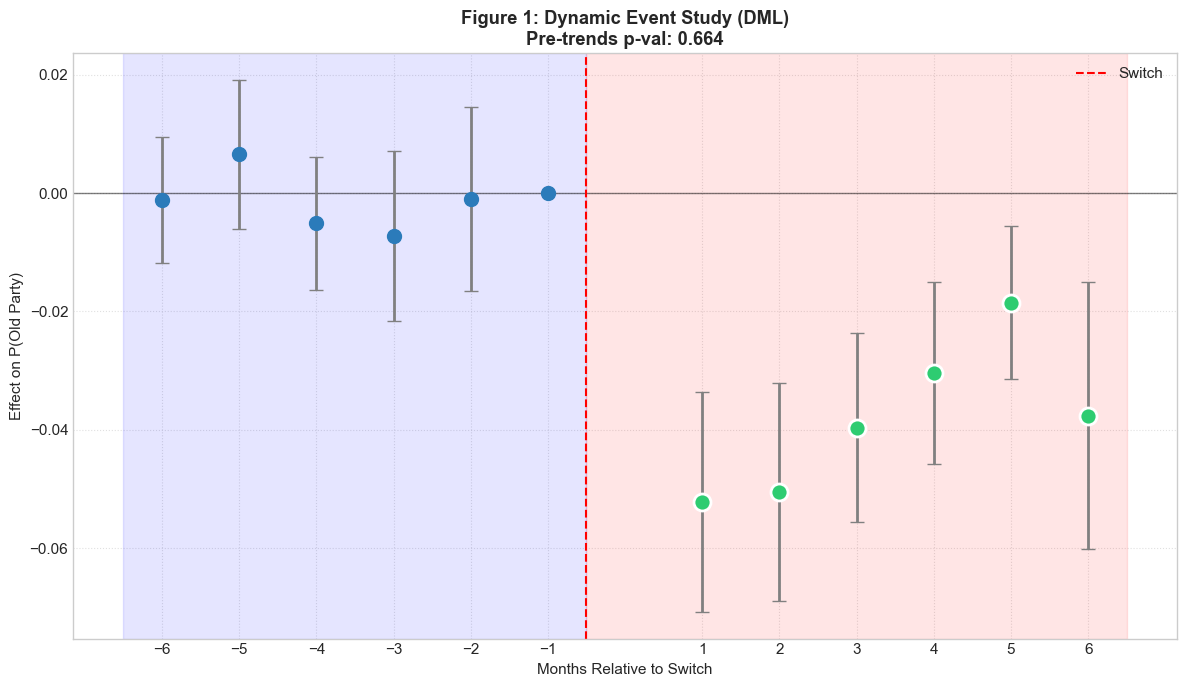

In [15]:
# =============================================================================
# SECTION 2 REPORT
# =============================================================================
def print_full_section2_report(general_stats, dml_data):
    print("="*60)
    print("SECTION 2: FULL ANALYSIS REPORT")
    print("="*60)
    print("\n")
    
    # 1. Classification & Data Stats
    print("--- 1. Classifier & Data ---")
    if 'model_performance' in general_stats:
        print(f"CV Accuracy:     {general_stats['model_performance']['CV Accuracy']}")
        print(f"Training Size:   {general_stats['model_performance']['Training Samples']:,}")
    if 'event_study_data' in general_stats:
        print(f"Event Study N:   {general_stats['event_study_data']['Total Speech-Events']:,}")
    if 'correlation_analysis' in general_stats:
        corr = general_stats['correlation_analysis']
        if corr.get('Status') == 'Complete':
            print(f"Correlation N:   {corr['Switchers with Full Data']:,}")
            print(f"Avg Ling Effect: {corr['Avg Linguistic Effect']:.4f}")
    print("\n")

    # 2. DML Model Summary
    print("--- 2. DML Model Specification ---")
    print(f"Observations:    {dml_data['model_summary']['N_Observations']:,}")
    print(f"Clusters:        {dml_data['model_summary']['N_Clusters']:,}")
    print(f"Topic Controls:  {'Yes' if dml_data['model_summary']['Topic_Controls'] else 'No'}")
    print(f"R-squared:       {dml_data['model_summary']['R_squared']:.4f}")
    print("\n")

    # 3. Pre-trends Test
    pt = dml_data['pretrends']
    print("--- 3. Pre-trends Test (Parallel Trends) ---")
    print(f"H0: All pre-period effects = 0")
    print(f"F-statistic:     {pt['f_stat']:.3f}")
    print(f"P-value:         {pt['p_value']:.4f}")
    
    if pt['passed']:
        print("RESULT: ✅ PASS (p > 0.10).")
    elif pt['marginal']:
        print("RESULT: ⚠️ MARGINAL (0.05 < p < 0.10).")
    else:
        print("RESULT: ❌ FAIL (p < 0.05).")
    print("\n")

    # 4. Detailed Regression Output (New Addition)
    print("--- 4. Detailed Regression Results ---")
    if 'results_table' in dml_data:
        # Create a formatted copy for clean printing
        df_res = dml_data['results_table'].copy()
        # Use to_string to ensure all rows are shown and not truncated
        print(df_res.applymap(lambda x: f"{x:.4f}").to_string())
    else:
        print("No regression table available.")
    print("\n")
    
    # 5. Generate Plot
    print("--- 5. Event Study Plot ---")
    plot_data = dml_data['plot_data']
    
    fig, ax = plt.subplots(figsize=(12,7))
    ax.axhline(0, color='black', lw=1, alpha=0.5)
    ax.axvline(-0.5, color='red', ls='--', lw=1.5, label='Switch')
    ax.axvspan(-6.5,-0.5, alpha=0.1, color='blue')
    ax.axvspan(-0.5,6.5, alpha=0.1, color='red')
    
    # Error bars
    ax.errorbar(plot_data['time'], plot_data['coef'],
                yerr=[plot_data['coef']-plot_data['lower'], plot_data['upper']-plot_data['coef']],
                fmt='o', ms=10, capsize=5, color=COLORS.get('main', 'black'), ecolor='gray', lw=2)
    
    # Significant points
    sig_data = plot_data[plot_data['sig']]
    if not sig_data.empty:
        ax.scatter(sig_data['time'], sig_data['coef'], 
                   c=COLORS.get('sig', 'red'), s=150, zorder=10, edgecolors='white', lw=2)
    
    ax.set_xlabel('Months Relative to Switch')
    ax.set_ylabel('Effect on P(Old Party)')
    ax.set_title(f'Figure 1: Dynamic Event Study (DML)\nPre-trends p-val: {pt["p_value"]:.3f}', fontweight='bold')
    ax.set_xticks(plot_data['time'])
    ax.legend()
    ax.grid(True, ls=':', alpha=0.6)
    
    plt.tight_layout()
    if 'PLOTS_DIR' in globals():
        plt.savefig(os.path.join(PLOTS_DIR, 'fig1_event_study.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("="*60)

# Pass both stats dictionaries to the report
print_full_section2_report(section2_stats, dml_stats)

## LANGUAGE VS VOTING BEHAVIOR

In [16]:
# LINGUISTIC VS VOTING BEHAVIOR (COMPUTATION) ================================
# =============================================================================
from scipy.stats import pearsonr, spearmanr, norm, t
from scipy.optimize import brentq
import numpy as np

# Initialize stats container
section2_1_stats = {}

# 1. CORRELATION ANALYSIS -----------------------------------------------------
if 'df_corr' in locals() and len(df_corr) >= 10:
    # Calculate correlation
    r_pearson, p_pearson = pearsonr(df_corr['abs_linguistic_effect'], df_corr['loyalty_increase'])
    r_spearman, p_spearman = spearmanr(df_corr['abs_linguistic_effect'], df_corr['loyalty_increase'])
    
    section2_1_stats['correlation'] = {
        'status': 'Complete',
        'n': len(df_corr),
        'r_pearson': r_pearson,
        'p_pearson': p_pearson,
        'r_spearman': r_spearman,
        'p_spearman': p_spearman,
        # Store data for plotting
        'x_data': df_corr['abs_linguistic_effect'].values,
        'y_data': df_corr['loyalty_increase'].values
    }
    
    # Store for persistence
    VOTING_RESULTS = section2_1_stats['correlation'].copy()
    VOTING_RESULTS['passes'] = p_pearson < 0.05 and r_pearson > 0.20
    VOTING_RESULTS['skipped'] = False
    %store VOTING_RESULTS

    # 2. POWER ANALYSIS -------------------------------------------------------
    n_current = len(df_corr)
    
    def power_for_correlation(n, r, alpha=0.05):
        z_r = np.arctanh(r)
        se = 1 / np.sqrt(n - 3)
        z_crit = norm.ppf(1 - alpha/2)
        ncp = z_r / se
        return 1 - norm.cdf(z_crit - ncp) + norm.cdf(-z_crit - ncp)

    def min_detectable_r(n, power=0.80, alpha=0.05):
        try:
            return brentq(lambda r: power_for_correlation(n, r, alpha) - power, 0.01, 0.95)
        except:
            return np.nan

    # Calculate Power Stats
    r_min_80 = min_detectable_r(n_current, power=0.80)
    r_min_50 = min_detectable_r(n_current, power=0.50)
    
    effect_sizes = [0.10, 0.20, 0.30, 0.40, 0.50]
    power_curve = {r: power_for_correlation(n_current, r) for r in effect_sizes}
    
    # Calculate Sample Size Needs
    n_needed_for_80 = {}
    for r_target in [0.10, 0.20, 0.30]:
        z_alpha = norm.ppf(1 - 0.05/2)
        z_beta = norm.ppf(0.80)
        z_r = np.arctanh(r_target)
        n_needed_for_80[r_target] = int(np.ceil(((z_alpha + z_beta) / z_r)**2 + 3))

    section2_1_stats['power_analysis'] = {
        'n_current': n_current,
        'mde_80': r_min_80,
        'mde_50': r_min_50,
        'power_curve': power_curve,
        'n_needed': n_needed_for_80
    }
    
    # 3. EQUIVALENCE TESTING (TOST) -------------------------------------------
    delta = 0.20  # Equivalence margin
    t_upper = (r_pearson - delta) / (1 / np.sqrt(n_current - 3))
    p_upper = t.cdf(t_upper, df=n_current - 3)
    
    t_lower = (r_pearson + delta) / (1 / np.sqrt(n_current - 3))
    p_lower = 1 - t.cdf(t_lower, df=n_current - 3)
    p_tost = max(p_upper, p_lower)
    
    section2_1_stats['equivalence'] = {
        'margin': delta,
        'p_tost': p_tost,
        'is_equivalent': p_tost < 0.05
    }
    
    # Store Power Results for persistence
    POWER_RESULTS = {
        'n': n_current, 'r_observed': r_pearson, 'p_observed': p_pearson,
        'mde_80': r_min_80, 'tost_p': p_tost, 'equivalence_shown': p_tost < 0.05
    }
    %store POWER_RESULTS

else:
    section2_1_stats['correlation'] = {'status': 'Skipped (N < 10)', 'n': len(df_corr) if 'df_corr' in locals() else 0}

Stored 'VOTING_RESULTS' (dict)
Stored 'POWER_RESULTS' (dict)


In [17]:
# =============================================================================
# SECTION 2.1 REPORT: CORRELATION & POWER (TEXT ONLY)
# =============================================================================
import numpy as np
import pandas as pd
from scipy.stats import norm

def print_section2_1_report(stats):
    print("="*60)
    print("SECTION 2.1: LANGUAGE VS VOTING BEHAVIOR REPORT")
    print("="*60)
    print("\n")
    
    corr = stats['correlation']
    if corr['status'] != 'Complete':
        print(f"⚠️ Analysis Skipped: {corr['status']}")
        return

    # -------------------------------------------------------------------------
    # 1. CORRELATION RESULTS
    # -------------------------------------------------------------------------
    r_p = corr['r_pearson']
    p_p = corr['p_pearson']
    n = corr['n']

    print("--- 1. Correlation Analysis ---")
    print(f"Observed N:       {n}")
    print(f"Pearson r:        {r_p:+.3f} (p={p_p:.4f})")
    print(f"Spearman r:       {corr['r_spearman']:+.3f} (p={corr['p_spearman']:.4f})")
    
    print(f"\n📊 INTERPRETATION:")
    if p_p < 0.05 and r_p > 0.20:
        print(f"   ✅✅✅ STRONG EVIDENCE: Language predicts behavior")
        print(f"   → r = {r_p:.3f} is substantively meaningful")
        print(f"   → Deputies who adapt language more also shift voting more")
        print(f"   → Evidence AGAINST cheap talk")
    elif p_p < 0.05 and r_p > 0.10:
        print(f"   ✅ MODERATE: Significant but modest correlation")
        print(f"   → Some evidence against cheap talk")
    elif p_p < 0.05:
        print(f"   ⚠️ WEAK: Significant but very small correlation")
    else:
        print(f"   ❌ NULL: No significant correlation (p={p_p:.4f})")
        print(f"   → Language does NOT predict behavior")
        print(f"   → Evidence FOR cheap talk interpretation")
    print("\n")

    # -------------------------------------------------------------------------
    # 2. POWER ANALYSIS (VERBOSE)
    # -------------------------------------------------------------------------
    pwr = stats['power_analysis']
    n_current = pwr['n_current']
    
    print("--- 2. Statistical Power Analysis ---")
    print(f"Sample Size (N): {n_current}")
    print(f"Min Detectable Effect (80% power): |r| ≥ {pwr['mde_80']:.3f}")
    
    # Re-define helper locally for verbosity generation
    def calc_power(n, r, alpha=0.05):
        z_r = np.arctanh(r)
        se = 1 / np.sqrt(n - 3)
        z_crit = norm.ppf(1 - alpha/2)
        return 1 - norm.cdf(z_crit - (z_r/se)) + norm.cdf(-z_crit - (z_r/se))

    # A. Power Table
    print(f"\nA. Statistical Power with Current N ({n_current}):")
    print(f"{'Target r':>10s} | {'Power':>8s} | {'Interpretation'}")
    print("-" * 50)
    
    effect_scenarios = [
        (0.10, "Very small (negligible)"),
        (0.15, "Small"),
        (0.20, "Small-moderate"),
        (0.25, "Moderate"),
        (0.30, "Moderate (medium)"),
        (0.40, "Large")
    ]
    
    for r_target, label in effect_scenarios:
        p_val = calc_power(n_current, r_target)
        print(f"{r_target:>10.2f} | {p_val:>7.1%}  | {label}")

    # B. Assessment
    print(f"\n   👉 ASSESSMENT:")
    if pwr['mde_80'] > 0.30:
        print("      ⚠️ UNDERPOWERED. Can only detect large effects (r > 0.30).")
        print("      Null results are ambiguous.")
    elif pwr['mde_80'] > 0.20:
        print("      ⚠️ MODERATELY POWERED. Misses small effects (r < 0.20).")
    else:
        print("      ✅ WELL-POWERED. Can detect small effects.")

    # C. N Needed Table
    print(f"\nB. Sample Size Required for 80% Power:")
    print(f"{'Target r':>10s} | {'N Needed':>8s} | {'Gap'}")
    print("-" * 50)
    
    for r_target in [0.10, 0.15, 0.20, 0.25, 0.30]:
        z_alpha = norm.ppf(1 - 0.05/2)
        z_beta = norm.ppf(0.80)
        z_r = np.arctanh(r_target)
        n_req = int(np.ceil(((z_alpha + z_beta) / z_r)**2 + 3))
        gap = n_req - n_current
        status = "✅ OK" if gap <= 0 else f"Need +{gap}"
        print(f"{r_target:>10.2f} | {n_req:>8d} | {status}")
    print("\n")

    # -------------------------------------------------------------------------
    # 3. EQUIVALENCE TESTING
    # -------------------------------------------------------------------------
    eq = stats['equivalence']
    print("--- 3. Equivalence Testing (TOST) ---")
    print(f"Goal: Prove correlation is negligible (closer to 0 than ±{eq['margin']})")
    print(f"Equivalence Margin (Δ): ±{eq['margin']}")
    print(f"TOST p-value:           {eq['p_tost']:.4f}")
    
    if eq['is_equivalent']:
        print(f"\n   ✅ EQUIVALENCE DEMONSTRATED (p < 0.05)")
        print(f"   → We can statistically claim the effect is negligible (|r| < {eq['margin']})")
        print(f"   → Strong evidence that language changes are unrelated to voting.")
    else:
        print(f"\n   ❌ EQUIVALENCE NOT SHOWN (p >= 0.05)")
        print(f"   → We cannot rule out a meaningful effect.")
        print(f"   → If correlation was non-significant, the result is inconclusive.")
    
    print("="*60)

print_section2_1_report(section2_1_stats)

SECTION 2.1: LANGUAGE VS VOTING BEHAVIOR REPORT


--- 1. Correlation Analysis ---
Observed N:       149
Pearson r:        -0.039 (p=0.6360)
Spearman r:       +0.070 (p=0.3958)

📊 INTERPRETATION:
   ❌ NULL: No significant correlation (p=0.6360)
   → Language does NOT predict behavior
   → Evidence FOR cheap talk interpretation


--- 2. Statistical Power Analysis ---
Sample Size (N): 149
Min Detectable Effect (80% power): |r| ≥ 0.228

A. Statistical Power with Current N (149):
  Target r |    Power | Interpretation
--------------------------------------------------
      0.10 |   22.8%  | Very small (negligible)
      0.15 |   44.7%  | Small
      0.20 |   68.8%  | Small-moderate
      0.25 |   87.0%  | Moderate
      0.30 |   96.2%  | Moderate (medium)
      0.40 |   99.9%  | Large

   👉 ASSESSMENT:
      ⚠️ MODERATELY POWERED. Misses small effects (r < 0.20).

B. Sample Size Required for 80% Power:
  Target r | N Needed | Gap
--------------------------------------------------
      0.1

# ROBUSTNESS

In [18]:
# SECTION 3: MODEL COMPARISON =================================================
# =============================================================================
import statsmodels.api as sm
from scipy.stats import pearsonr

# Initialize container
section3_stats = {}

print("Running robustness checks (OLS vs TWFE vs DML)...")

# 1. DATA PREPARATION ---------------------------------------------------------
# Prepare data (same logic as main DML)
bins_comp = list(range(-180, 181, 30))
labels_comp = [-6,-5,-4,-3,-2,-1,1,2,3,4,5,6]
df_es_comp = df_es.dropna(subset=['Y_confidence']).copy()
df_es_comp['month'] = pd.cut(df_es_comp['days_from_switch'], bins=bins_comp, labels=labels_comp)

time_dummies_comp = pd.get_dummies(df_es_comp['month'], prefix='t')
if 't_-1' in time_dummies_comp.columns:
    time_dummies_comp = time_dummies_comp.drop(columns=['t_-1'])

# Force floats
time_dummies_comp = time_dummies_comp.astype(float)

# Covariates
cov_cols_comp = [c for c in ['gov_loyalty_12m', 'party_tenure_months', 'EST'] if c in df_es_comp.columns]
X_cov_comp = df_es_comp[cov_cols_comp].apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)

# Legislature dummies
X_leg_comp = pd.get_dummies(df_es_comp['idLegislatura'], prefix='leg').astype(float)

# Topic controls
if 'topic_id' in df_es_comp.columns:
    X_topic_comp = pd.get_dummies(df_es_comp['topic_id'], prefix='topic', drop_first=True).astype(float)
else:
    X_topic_comp = pd.DataFrame(index=df_es_comp.index)

Y_comp = df_es_comp['Y_confidence'].values
clusters_comp = df_es_comp['deputado_id'].values

# 2. METHOD 1: STANDARD OLS ---------------------------------------------------
print("   Fitting Method 1: Standard OLS...")
X_ols = pd.concat([time_dummies_comp, X_cov_comp, X_leg_comp, X_topic_comp], axis=1)

# Safety check for object columns
if X_ols.select_dtypes(include=['object']).shape[1] > 0:
    X_ols = X_ols.astype(float)

model_ols = sm.OLS(Y_comp, X_ols).fit(cov_type='cluster', cov_kwds={'groups': clusters_comp})

# Extract coefficients
coefs_ols = model_ols.params[[c for c in model_ols.params.index if c.startswith('t_')]]
ses_ols = model_ols.bse[[c for c in model_ols.params.index if c.startswith('t_')]]

section3_stats['OLS'] = {
    'R2': model_ols.rsquared,
    'Peak_Effect': coefs_ols.get('t_2', np.nan),
    'N': len(Y_comp)
}

# 3. METHOD 2: TWO-WAY FIXED EFFECTS (TWFE) -----------------------------------
print("   Fitting Method 2: Two-Way Fixed Effects (Deputy + Month)...")

# A. Deputy FE
deputy_dummies = pd.get_dummies(df_es_comp['deputado_id'], prefix='dep', drop_first=True).astype(float)

# B. Calendar Month FE
df_es_comp['calendar_month'] = df_es_comp['dataHoraInicio'].dt.to_period('M').astype(str)
month_dummies = pd.get_dummies(df_es_comp['calendar_month'], prefix='cal_month', drop_first=True).astype(float)

# C. Time-Varying Covariates (State 'EST' absorbed by Deputy FE)
time_varying_cov = ['gov_loyalty_12m', 'party_tenure_months']
X_cov_twfe = df_es_comp[time_varying_cov].apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)

# Combine Matrix
X_twfe = pd.concat([time_dummies_comp, X_cov_twfe, X_topic_comp, deputy_dummies, month_dummies], axis=1)
X_twfe = sm.add_constant(X_twfe)

# Fit Model
model_twfe = sm.OLS(Y_comp, X_twfe).fit(cov_type='cluster', cov_kwds={'groups': clusters_comp})

coefs_twfe = model_twfe.params[[c for c in model_twfe.params.index if c.startswith('t_')]]
ses_twfe = model_twfe.bse[[c for c in model_twfe.params.index if c.startswith('t_')]]

section3_stats['TWFE'] = {
    'R2': model_twfe.rsquared,
    'Peak_Effect': coefs_twfe.get('t_2', np.nan),
    'N_Vars': X_twfe.shape[1]
}

# 4. METHOD 3: RETRIEVE DML RESULTS -------------------------------------------
# Attempt to retrieve plot_data from previous section (dml_stats)
if 'dml_stats' in globals() and 'plot_data' in dml_stats:
    plot_data_ref = dml_stats['plot_data']
    coefs_dml = plot_data_ref.set_index('time')['coef']
    ses_dml = (plot_data_ref.set_index('time')['upper'] - plot_data_ref.set_index('time')['lower']) / 3.92
    
    section3_stats['DML'] = {
        'Peak_Effect': coefs_dml.get(2, np.nan),
        'Available': True
    }
else:
    coefs_dml = pd.Series(dtype=float)
    ses_dml = pd.Series(dtype=float)
    section3_stats['DML'] = {'Available': False}

# 5. BUILD COMPARISON DATA ----------------------------------------------------
comparison_data = []
for time_point in [-6,-5,-4,-3,-2,1,2,3,4,5,6]:
    comparison_data.append({
        'time': time_point,
        'OLS': coefs_ols.get(f't_{time_point}', np.nan),
        'OLS_se': ses_ols.get(f't_{time_point}', np.nan),
        'TWFE': coefs_twfe.get(f't_{time_point}', np.nan),
        'TWFE_se': ses_twfe.get(f't_{time_point}', np.nan),
        'DML': coefs_dml.get(time_point, np.nan),
        'DML_se': ses_dml.get(time_point, np.nan)
    })

df_comparison = pd.DataFrame(comparison_data)
section3_stats['comparison_table'] = df_comparison

# 6. CALCULATE CORRELATIONS ---------------------------------------------------
valid_idx = df_comparison[['OLS','TWFE','DML']].notna().all(axis=1)
if valid_idx.sum() > 2:
    corr_ols_dml, _ = pearsonr(df_comparison.loc[valid_idx, 'OLS'], df_comparison.loc[valid_idx, 'DML'])
    corr_twfe_dml, _ = pearsonr(df_comparison.loc[valid_idx, 'TWFE'], df_comparison.loc[valid_idx, 'DML'])
    
    section3_stats['correlations'] = {
        'OLS_vs_DML': corr_ols_dml,
        'TWFE_vs_DML': corr_twfe_dml,
        'Calculated': True
    }
else:
    section3_stats['correlations'] = {'Calculated': False}

print("Robustness checks complete.")

Running robustness checks (OLS vs TWFE vs DML)...
   Fitting Method 1: Standard OLS...
   Fitting Method 2: Two-Way Fixed Effects (Deputy + Month)...
Robustness checks complete.


In [19]:
# PREPARE METHOD COMPARISON PLOT DATA =========================================
# =============================================================================

# Calculate correlation annotation text for the plot
# This ensures the logic remains here, but the rendering happens in the report
if section3_stats.get('correlations', {}).get('Calculated'):
    c = section3_stats['correlations']
    corr_text = f"Correlations with DML:\n"
    corr_text += f"  OLS:  r = {c['OLS_vs_DML']:.3f}\n"
    corr_text += f"  TWFE: r = {c['TWFE_vs_DML']:.3f}"
    
    section3_stats['plot_annotation'] = corr_text
else:
    section3_stats['plot_annotation'] = None

# Store plot labels and metadata if needed for custom formatting later
section3_stats['plot_config'] = {
    'labels': {
        'OLS': 'OLS',
        'TWFE': 'TWFE (Legislature FE)',
        'DML': 'DML (Main)'
    },
    'colors': {
        'OLS': '#3498db',
        'TWFE': '#9b59b6'
    }
}

In [20]:
# ROBUSTNESS: ALTERNATIVE TEXT REPRESENTATION (Level 3) ==========================
# =============================================================================

print("Running Robustness Check: Alternative Text Representation (Level 3)...")

# 1. SETUP & TRAINING ---------------------------------------------------------
# Define the alternative column
ALT_TEXT_COL = 'text_level_3'  # Assuming this is the column name in your DF

if ALT_TEXT_COL in df.columns:
    print(f"   Using text column: {ALT_TEXT_COL}")
    
    # Initialize Vectorizer for Level 3
    # We use the same parameters as main model for fair comparison
    tfidf_alt = TfidfVectorizer(max_features=CFG.tfidf_max_features, 
                                min_df=CFG.tfidf_min_df,
                                max_df=CFG.tfidf_max_df, 
                                ngram_range=(1,2))
    
    # Train on the alternative text column
    # Note: df_train indices must match what we used before
    X_train_alt = tfidf_alt.fit_transform(df_train[ALT_TEXT_COL])
    y_train_alt = df_train['idPartido']
    
    clf_alt = LogisticRegression(class_weight='balanced', C=1.0, 
                                 max_iter=500, n_jobs=-1, random_state=SEED)
    clf_alt.fit(X_train_alt, y_train_alt)
    
    # 2. GENERATE NEW CONFIDENCE SCORES ---------------------------------------
    print("   Generating new confidence scores...")
    
    # Create a temporary copy for this robustness check to avoid polluting main df_es
    df_es_rob = df_es.copy()
    
    # Predict directly on the event study rows using the new text
    X_es_alt = tfidf_alt.transform(df_es_rob[ALT_TEXT_COL])
    probs_alt = list(clf_alt.predict_proba(X_es_alt))
    
    # Helper to extract confidence
    # We need to recreate the class index map for this specific classifier
    ALT_CLASS_INDICES = {label: idx for idx, label in enumerate(clf_alt.classes_)}
    
    def get_conf_alt(row, probs, ci):
        pid = str(row['old_party_id'])
        # Use row index to fetch probability from the list we just created
        # (This relies on X_es_alt order matching df_es_rob)
        return probs[ci[pid]] if pid in ci else np.nan

    # Map probabilities to rows
    # We zip the probabilities to ensure alignment
    df_es_rob['probs_temp'] = probs_alt
    df_es_rob['Y_confidence_alt'] = df_es_rob.apply(
        lambda r: r['probs_temp'][ALT_CLASS_INDICES.get(str(r['old_party_id']))] 
                  if str(r['old_party_id']) in ALT_CLASS_INDICES else np.nan, 
        axis=1
    )
    
    df_es_rob = df_es_rob.dropna(subset=['Y_confidence_alt'])

    # 3. RUN DML ON NEW SCORES ------------------------------------------------
    print("   Re-running DML...")
    
    # Use the same control matrix X from the main analysis to ensure comparability
    # (We reconstruct it quickly to be safe)
    # ... [Same Feature Construction as Cell 1] ...
    
    # Time dummies
    time_dummies_rob = pd.get_dummies(df_es_rob['month'], prefix='t')
    if 't_-1' in time_dummies_rob.columns: time_dummies_rob = time_dummies_rob.drop(columns=['t_-1'])
    
    # Covariates
    cov_cols = [c for c in ['gov_loyalty_12m','party_tenure_months'] if c in df_es_rob.columns]
    X_cov = df_es_rob[cov_cols].fillna(0)
    X_leg = pd.get_dummies(df_es_rob['idLegislatura'], prefix='leg')
    if 'topic_id' in df_es_rob.columns:
        X_topic = pd.get_dummies(df_es_rob['topic_id'], prefix='topic', drop_first=True)
    else:
        X_topic = pd.DataFrame(index=df_es_rob.index)
        
    X_rob = pd.concat([X_cov, X_leg, X_topic], axis=1)
    Y_rob = df_es_rob['Y_confidence_alt'].values
    clusters_rob = df_es_rob['deputado_id'].values
    
    # DML Estimators
    learner_Y = HistGradientBoostingRegressor(max_iter=100, max_depth=5, random_state=SEED)
    learner_D = HistGradientBoostingClassifier(max_iter=50, max_depth=3, random_state=SEED)
    kf = KFold(n_splits=CFG.dml_n_splits, shuffle=True, random_state=SEED)
    
    # Residualize Y
    Y_pred = cross_val_predict(learner_Y, X_rob, Y_rob, cv=kf)
    Y_resid = Y_rob - Y_pred
    
    # Residualize D
    D_resid = pd.DataFrame(index=df_es_rob.index, columns=time_dummies_rob.columns, dtype=float)
    for col in tqdm(time_dummies_rob.columns, desc="   DML Residualizing"):
        D_pred = cross_val_predict(learner_D, X_rob, time_dummies_rob[col], cv=kf, method='predict_proba')[:,1]
        D_resid[col] = time_dummies_rob[col] - D_pred
        
    # Final OLS
    X_final_rob = sm.add_constant(D_resid)
    results_rob = sm.OLS(Y_resid, X_final_rob).fit(cov_type='cluster', cov_kwds={'groups': clusters_rob})
    
    # 4. STORE RESULTS --------------------------------------------------------
    coefs_rob = results_rob.params.drop('const')
    
    section3_stats['robustness_text'] = {
        'status': 'Complete',
        'col_name': ALT_TEXT_COL,
        'coefs': coefs_rob.to_dict(),
        'peak_effect': coefs_rob.get('t_2', np.nan),
        'n_obs': len(Y_rob)
    }
    print(f"   Robustness check complete. Peak effect (t+2): {coefs_rob.get('t_2', np.nan):.4f}")

else:
    print(f"   ⚠️ Column '{ALT_TEXT_COL}' not found in dataframe. Skipping check.")
    section3_stats['robustness_text'] = {'status': 'Skipped (Missing Column)'}

Running Robustness Check: Alternative Text Representation (Level 3)...
   Using text column: text_level_3
   Generating new confidence scores...
   Re-running DML...


   DML Residualizing: 100%|██████████| 11/11 [00:08<00:00,  1.37it/s]

   Robustness check complete. Peak effect (t+2): -0.0293


In [21]:
# ROBUSTNESS: BLOC-LEVEL CLASSIFIER (Left vs Center vs Right) =================
# =============================================================================
print("Running Robustness Check: Bloc-Level Classifier (Left/Center/Right)...")

# 1. TRAIN CLASSIFIER ---------------------------------------------------------
# We use 'CAT' (Ideological Category) as the target instead of 'idPartido'
if 'CAT' in df_train.columns and df_train['CAT'].nunique() > 1:
    
    # Initialize Vectorizer (slightly fewer features typically sufficient for broader categories)
    tfidf_bloc = TfidfVectorizer(max_features=3000, min_df=10, max_df=0.8, ngram_range=(1,2))
    X_bloc = tfidf_bloc.fit_transform(df_train[CFG.text_col])
    y_bloc = df_train['CAT']  # Target: Ideology (Left, Center, Right)

    clf_bloc = LogisticRegression(class_weight='balanced', C=1.0, max_iter=500, n_jobs=-1, random_state=SEED)
    clf_bloc.fit(X_bloc, y_bloc)

    cv_bloc = cross_val_score(clf_bloc, X_bloc, y_bloc, cv=5)
    
    section3_stats['bloc_robustness'] = {
        'status': 'Complete',
        'cv_accuracy': cv_bloc.mean(),
        'classes': list(clf_bloc.classes_)
    }

    # 2. GENERATE PREDICTIONS -------------------------------------------------
    BLOC_CI = {l:i for i,l in enumerate(clf_bloc.classes_)}
    
    # Predict directly on event study dataframe (safest method)
    # Filter df_es to only rows where we have valid old/new Categories
    df_es_bloc = df_es.dropna(subset=['old_CAT', 'new_CAT', CFG.text_col]).copy()
    
    X_es_bloc = tfidf_bloc.transform(df_es_bloc[CFG.text_col])
    probs_bloc = list(clf_bloc.predict_proba(X_es_bloc))
    
    # Helper to extract probability of OLD ideological block
    def get_bloc_conf(row, probs, ci):
        old_cat = row['old_CAT']
        if old_cat in ci:
            return probs[ci[old_cat]]
        return np.nan

    # Map probabilities
    df_es_bloc['probs_temp'] = probs_bloc
    df_es_bloc['Y_bloc'] = df_es_bloc.apply(
        lambda r: r['probs_temp'][BLOC_CI[r['old_CAT']]] if r['old_CAT'] in BLOC_CI else np.nan, 
        axis=1
    )
    df_es_bloc = df_es_bloc.dropna(subset=['Y_bloc'])

    # 3. COMPARE PRE VS POST --------------------------------------------------
    df_es_bloc['post'] = (df_es_bloc['days_from_switch'] > 0).astype(int)
    
    pre_bloc = df_es_bloc[df_es_bloc['post']==0]['Y_bloc']
    post_bloc = df_es_bloc[df_es_bloc['post']==1]['Y_bloc']
    
    # T-test
    bloc_diff = post_bloc.mean() - pre_bloc.mean()
    bloc_t, bloc_p = stats.ttest_ind(post_bloc, pre_bloc, equal_var=False)
    
    # Cohen's d (Effect Size)
    pooled_std = np.sqrt((pre_bloc.std()**2 + post_bloc.std()**2)/2)
    bloc_d = bloc_diff / pooled_std

    # Store results
    section3_stats['bloc_robustness'].update({
        'n_obs': len(df_es_bloc),
        'diff': bloc_diff,
        't_stat': bloc_t,
        'p_value': bloc_p,
        'cohens_d': bloc_d,
        'pre_mean': pre_bloc.mean(),
        'post_mean': post_bloc.mean()
    })
    
    print(f"   Bloc Acc: {cv_bloc.mean():.3f} | Diff: {bloc_diff:+.4f} | p={bloc_p:.4f} | d={bloc_d:.3f}")

else:
    print("   ⚠️ 'CAT' column missing or invalid. Skipping Bloc check.")
    section3_stats['bloc_robustness'] = {'status': 'Skipped (Missing CAT)'}

Running Robustness Check: Bloc-Level Classifier (Left/Center/Right)...
   Bloc Acc: 0.512 | Diff: -0.0138 | p=0.0000 | d=-0.064


In [22]:
# ROBUSTNESS: EMBEDDING SIMILARITY (Semantic Distance) ========================
# =============================================================================
from scipy.spatial.distance import cosine
import numpy as np
import scipy.stats as stats

print("Running Robustness Check: Embedding Similarity...")

# Initialize stats container entry
section3_stats['embedding_robustness'] = {'status': 'Initialized'}

# Check if embedding data is available
if 'embedding' in df.columns:
    
    # 1. COMPUTE MEAN PARTY EMBEDDINGS (CENTROIDS) ----------------------------
    def safe_mean_emb(embs):
        # Filter out None or empty entries
        valid = [np.array(e) for e in embs if e is not None and len(np.array(e).shape) > 0]
        return np.mean(np.vstack(valid), axis=0) if valid else None

    PARTY_EMB = {}
    # Use df_train to avoid data leakage (only training data defines the "party core")
    for pid in df_train['idPartido'].unique():
        embs = df_train[df_train['idPartido'] == pid]['embedding'].dropna().tolist()
        if len(embs) >= CFG.min_party_speeches:
            PARTY_EMB[pid] = safe_mean_emb(embs)
            
    section3_stats['embedding_robustness']['n_parties_with_emb'] = len(PARTY_EMB)

    # 2. CALCULATE SIMILARITY TO OLD PARTY ------------------------------------
    def cos_sim(a, b):
        if a is None or b is None: return None
        a = np.array(a).flatten()
        b = np.array(b).flatten()
        if len(a) != len(b): return None
        return 1 - cosine(a, b)

    # Create local copy for analysis
    df_es_emb = df_es.copy()
    
    # Ensure embeddings are attached to df_es (if not already)
    if 'embedding' not in df_es_emb.columns:
        # Merge if missing (assuming index alignment or merging by ID/Date)
        # For safety, we map from main df using index if preserved, or assume it's there
        df_es_emb['embedding'] = df.loc[df_es_emb.index, 'embedding']

    df_es_emb['sim_old'] = df_es_emb.apply(
        lambda r: cos_sim(r['embedding'], PARTY_EMB.get(str(r['old_party_id']))), 
        axis=1
    )
    
    df_es_emb = df_es_emb.dropna(subset=['sim_old'])

    # 3. STATISTICAL TEST (Pre vs Post) ---------------------------------------
    df_es_emb['post'] = (df_es_emb['days_from_switch'] > 0).astype(int)

    pre_emb = df_es_emb[df_es_emb['post'] == 0]['sim_old']
    post_emb = df_es_emb[df_es_emb['post'] == 1]['sim_old']
    
    if len(pre_emb) > 1 and len(post_emb) > 1:
        emb_diff = post_emb.mean() - pre_emb.mean()
        emb_t, emb_p = stats.ttest_ind(post_emb, pre_emb, equal_var=False)
        emb_d = emb_diff / np.sqrt((pre_emb.std()**2 + post_emb.std()**2)/2)

        # Store results
        section3_stats['embedding_robustness'].update({
            'status': 'Complete',
            'n_obs': len(df_es_emb),
            'diff': emb_diff,
            't_stat': emb_t,
            'p_value': emb_p,
            'cohens_d': emb_d,
            'pre_mean': pre_emb.mean(),
            'post_mean': post_emb.mean()
        })
        
        print(f"   Emb Diff: {emb_diff:+.4f} | p={emb_p:.4f} | d={emb_d:.3f}")
    else:
        print("   ⚠️ Insufficient data for embedding t-test.")
        section3_stats['embedding_robustness']['status'] = 'Skipped (Insufficient Data)'

else:
    print("   ⚠️ 'embedding' column not found. Skipping Embedding check.")
    section3_stats['embedding_robustness']['status'] = 'Skipped (Missing Embeddings)'

Running Robustness Check: Embedding Similarity...
   Emb Diff: +0.0014 | p=0.0066 | d=0.024


In [23]:
# ROBUSTNESS: PLACEBO DISTRIBUTION TEST (Permutation Test) ====================
# =============================================================================
import numpy as np
from tqdm import tqdm

print("Running Robustness Check: Placebo Distribution Test...")

# 1. CALCULATE TRUE EFFECT (RAW Y) --------------------------------------------
# We use the raw outcome Y_confidence as residuals absorb timing info
true_post_mask = (df_es['days_from_switch'] >= 30) & (df_es['days_from_switch'] <= 150)
true_pre_mask = (df_es['days_from_switch'] >= -60) & (df_es['days_from_switch'] < 0)

true_effect_stat = abs(df_es.loc[true_post_mask, 'Y_confidence'].mean() - 
                       df_es.loc[true_pre_mask, 'Y_confidence'].mean())

# 2. RUN PERMUTATIONS ---------------------------------------------------------
n_permutations = 1000
placebo_stats = []
deputy_ids = df_es['deputado_id'].unique()

np.random.seed(SEED)

for i in tqdm(range(n_permutations), desc="   Running Permutations"):
    perm_seed = SEED + i
    np.random.seed(perm_seed)
    
    # Generate random date offsets (shift ± 1 year)
    offsets = np.random.randint(-365, 365, size=len(deputy_ids))
    deputy_offset_map = dict(zip(deputy_ids, offsets))
    
    # Apply offsets
    current_offsets = df_es['deputado_id'].map(deputy_offset_map)
    fake_days = df_es['days_from_switch'] - current_offsets
    
    # Calculate placebo effect using SAME windows
    fake_post = (fake_days >= 30) & (fake_days <= 150)
    fake_pre = (fake_days >= -60) & (fake_days < 0)
    
    # Require minimum observations to be valid
    if fake_post.sum() > 50 and fake_pre.sum() > 50:
        stat = abs(df_es.loc[fake_post, 'Y_confidence'].mean() - 
                   df_es.loc[fake_pre, 'Y_confidence'].mean())
        placebo_stats.append(stat)

placebo_stats = np.array(placebo_stats)

# 3. CALCULATE STATISTICS -----------------------------------------------------
p_value_lower = (placebo_stats >= true_effect_stat).mean()
p_value_two_tailed = 2 * min(p_value_lower, 1 - p_value_lower)
percentile = (placebo_stats <= true_effect_stat).mean() * 100

section3_stats['placebo'] = {
    'status': 'Complete',
    'true_effect': true_effect_stat,
    'placebo_stats': placebo_stats, # Stored for plotting
    'mean_placebo': placebo_stats.mean(),
    'percentile': percentile,
    'p_value': p_value_lower,
    'n_permutations': len(placebo_stats)
}

# Store for persistence
PLACEBO_RESULTS = section3_stats['placebo'].copy()
%store PLACEBO_RESULTS

print(f"   True Effect: {true_effect_stat:.4f} | Placebo P-val: {p_value_lower:.4f}")

Running Robustness Check: Placebo Distribution Test...


   Running Permutations: 100%|██████████| 1000/1000 [00:32<00:00, 30.60it/s]

Stored 'PLACEBO_RESULTS' (dict)
   True Effect: 0.0462 | Placebo P-val: 0.0000


In [24]:
# ROBUSTNESS: DML SENSITIVITY TO TIME WINDOWS ================================
# =============================================================================
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
import statsmodels.api as sm

print("Running Robustness Check: DML in Alternative Time Windows...")

# Initialize container
dml_window_results = []
windows_months = [6, 9, 12, 15, 18]

# DML Settings (Same as main analysis)
kf_rob = KFold(n_splits=5, shuffle=True, random_state=SEED)
learner_Y_rob = HistGradientBoostingRegressor(max_iter=100, max_depth=5, random_state=SEED)
learner_D_rob = HistGradientBoostingClassifier(max_iter=50, max_depth=3, random_state=SEED)

for wm in tqdm(windows_months, desc="   Running DML on Windows"):
    wd = wm * 30  # Days
    
    # 1. Filter Data
    tmp = df_es[df_es['days_from_switch'].abs() <= wd].copy()
    
    # 2. Define Treatment
    # We estimate the Average Treatment Effect (ATE) of being 'Post-Switch' within this window
    tmp['Post'] = (tmp['days_from_switch'] > 0).astype(int)
    
    # 3. Build Control Matrix (X)
    # Covariates
    cov_cols = [c for c in ['gov_loyalty_12m', 'party_tenure_months'] if c in tmp.columns]
    X_cov = tmp[cov_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    
    # Legislature FE
    X_leg = pd.get_dummies(tmp['idLegislatura'], prefix='leg')
    
    # Topic FE
    if 'topic_id' in tmp.columns:
        X_topic = pd.get_dummies(tmp['topic_id'], prefix='topic', drop_first=True)
    else:
        X_topic = pd.DataFrame(index=tmp.index)
        
    X_rob = pd.concat([X_cov, X_leg, X_topic], axis=1).astype(float)
    
    Y_rob = tmp['Y_confidence'].values
    D_rob = tmp['Post'].values  # Binary treatment for this window check
    clusters_rob = tmp['deputado_id'].values
    
    # 4. DML Procedure
    # A. Residualize Outcome (Y)
    Y_pred = cross_val_predict(learner_Y_rob, X_rob, Y_rob, cv=kf_rob)
    Y_resid = Y_rob - Y_pred
    
    # B. Residualize Treatment (D = Post)
    # We use classifier since 'Post' is binary
    D_pred = cross_val_predict(learner_D_rob, X_rob, D_rob, cv=kf_rob, method='predict_proba')[:,1]
    D_resid = D_rob - D_pred
    
    # C. Final OLS on Residuals
    # Y~ ~ D~ (No constant needed usually for pure residuals, but adding one is standard safety)
    X_final = sm.add_constant(D_resid)
    model_dml_win = sm.OLS(Y_resid, X_final).fit(cov_type='cluster', cov_kwds={'groups': clusters_rob})
    
    # 5. Store Results
    coef = model_dml_win.params[0] if len(model_dml_win.params) == 1 else model_dml_win.params[1]
    p_val = model_dml_win.pvalues[0] if len(model_dml_win.pvalues) == 1 else model_dml_win.pvalues[1]
    
    dml_window_results.append({
        'window_months': wm,
        'n_obs': len(tmp),
        'coef': coef,
        'p_value': p_val
    })
    
    sig = '*' if p_val < 0.05 else ''
    print(f"   {wm}mo Window (DML): ATE={coef:+.4f}, p={p_val:.4f} {sig}")

# Save to stats
section3_stats['window_sensitivity'] = {
    'status': 'Complete',
    'method': 'DML (ATE)',
    'results': pd.DataFrame(dml_window_results)
}

Running Robustness Check: DML in Alternative Time Windows...


   Running DML on Windows:  20%|██        | 1/5 [00:03<00:13,  3.26s/it]

   6mo Window (DML): ATE=-0.0359, p=0.0001 *


   Running DML on Windows:  40%|████      | 2/5 [00:07<00:11,  3.79s/it]

   9mo Window (DML): ATE=-0.0389, p=0.0000 *


...

   12mo Window (DML): ATE=-0.0385, p=0.0000 *


   Running DML on Windows:  80%|████████  | 4/5 [13:50<03:49, 229.54s/it]

   15mo Window (DML): ATE=-0.0384, p=0.0000 *


   Running DML on Windows: 100%|██████████| 5/5 [13:54<00:00, 166.88s/it]

   18mo Window (DML): ATE=-0.0384, p=0.0000 *


In [25]:
# ROBUSTNESS: ALTERNATIVE OUTCOME (P(New) - P(Old)) ===========================
# =============================================================================
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
import statsmodels.api as sm

print("Running Robustness Check: Alternative Outcome (P(New) - P(Old))...")

# 1. CALCULATE P(New) ---------------------------------------------------------
print("   Calculating P(New Party) for each speech...")

df_es_alt = df_es.copy()

# We need to map each deputy to their NEW party ID
# Using df_events which contains the switch details
# We create a map: deputy_id -> new_party_id
deputy_to_new_party = df_events.set_index('deputado_id')['new_party_id'].to_dict()

new_party_probs = []
# We iterate to extract the specific probability for the new party
# (Vectorizing this is possible but complex due to variable indices)
for idx, row in df_es_alt.iterrows():
    dep_id = row['deputado_id']
    new_pid = str(deputy_to_new_party.get(dep_id))
    
    # Get P(New Party)
    if new_pid in PARTY_CLASS_INDICES:
        new_idx = PARTY_CLASS_INDICES[new_pid]
        probs = row['party_probs']
        if probs is not None and len(probs) > new_idx:
            new_party_probs.append(probs[new_idx])
        else:
            new_party_probs.append(np.nan)
    else:
        new_party_probs.append(np.nan)

df_es_alt['P_new'] = new_party_probs
# Outcome: Difference between probability of new party and old party
df_es_alt['Y_alt'] = df_es_alt['P_new'] - df_es_alt['Y_confidence']

# Filter valid rows
df_es_alt = df_es_alt.dropna(subset=['Y_alt'])

section3_stats['alt_outcome'] = {
    'status': 'Initialized',
    'n_obs': len(df_es_alt)
}

# 2. RUN DML ON ALTERNATIVE OUTCOME -------------------------------------------
print(f"   Running DML on {len(df_es_alt):,} observations...")

# A. Prepare Matrix (Reusing logic for consistency)
# Time Dummies
bins = list(range(-180, 181, 30))
labels = [-6,-5,-4,-3,-2,-1,1,2,3,4,5,6]
df_es_alt['month'] = pd.cut(df_es_alt['days_from_switch'], bins=bins, labels=labels)
time_dummies_alt = pd.get_dummies(df_es_alt['month'], prefix='t')
if 't_-1' in time_dummies_alt.columns: time_dummies_alt = time_dummies_alt.drop(columns=['t_-1'])

# Controls
cov_cols = [c for c in ['gov_loyalty_12m','party_tenure_months'] if c in df_es_alt.columns]
X_cov = df_es_alt[cov_cols].fillna(0)
X_leg = pd.get_dummies(df_es_alt['idLegislatura'], prefix='leg')

if 'topic_id' in df_es_alt.columns:
    X_topic = pd.get_dummies(df_es_alt['topic_id'], prefix='topic', drop_first=True)
else:
    X_topic = pd.DataFrame(index=df_es_alt.index)

X_alt = pd.concat([X_cov, X_leg, X_topic], axis=1).astype(float)
Y_alt = df_es_alt['Y_alt'].values
clusters_alt = df_es_alt['deputado_id'].values

# B. DML Estimation
kf_alt = KFold(n_splits=5, shuffle=True, random_state=SEED)
learner_Y = HistGradientBoostingRegressor(max_iter=100, max_depth=5, random_state=SEED)
learner_D = HistGradientBoostingClassifier(max_iter=50, max_depth=3, random_state=SEED)

# Residualize Outcome
Y_pred = cross_val_predict(learner_Y, X_alt, Y_alt, cv=kf_alt)
Y_resid = Y_alt - Y_pred

# Residualize Treatments (Time Dummies)
D_resid = pd.DataFrame(index=df_es_alt.index, columns=time_dummies_alt.columns, dtype=float)
for col in tqdm(time_dummies_alt.columns, desc="   DML Residualizing"):
    D_pred = cross_val_predict(learner_D, X_alt, time_dummies_alt[col], cv=kf_alt, method='predict_proba')[:,1]
    D_resid[col] = time_dummies_alt[col] - D_pred

# Final OLS
X_final_alt = sm.add_constant(D_resid)
results_alt = sm.OLS(Y_resid, X_final_alt).fit(cov_type='cluster', cov_kwds={'groups': clusters_alt})

# 3. STORE RESULTS ------------------------------------------------------------
# Format data for plotting/comparison
coefs_alt = results_alt.params.drop('const')
ses_alt = results_alt.bse.drop('const')

plot_data_alt = pd.DataFrame({
    'time': [int(c.replace('t_', '')) for c in coefs_alt.index],
    'coef': coefs_alt.values,
    'se': ses_alt.values
}).sort_values('time')

# Calculate statistics for report
# Peak effect (usually t=1 to t=4)
peak_idx = (plot_data_alt['time'] >= 1) & (plot_data_alt['time'] <= 4)
peak_new_old = plot_data_alt.loc[peak_idx, 'coef'].max()

section3_stats['alt_outcome'].update({
    'status': 'Complete',
    'peak_effect': peak_new_old,
    'plot_data': plot_data_alt
})

# Store for persistence
ALTERNATIVE_OUTCOME_RESULTS = {
    'results_alt': results_alt, # Full model object
    'plot_data_alt': plot_data_alt,
    'peak_new_old': peak_new_old
}
%store ALTERNATIVE_OUTCOME_RESULTS

print(f"   Robustness check complete. Peak P(New)-P(Old): {peak_new_old:+.4f}")

Running Robustness Check: Alternative Outcome (P(New) - P(Old))...
   Calculating P(New Party) for each speech...
   Running DML on 41,242 observations...


   DML Residualizing: 100%|██████████| 11/11 [00:09<00:00,  1.19it/s]

Stored 'ALTERNATIVE_OUTCOME_RESULTS' (dict)
   Robustness check complete. Peak P(New)-P(Old): +0.0656


In [26]:
# ROBUSTNESS: COMPOSITION EFFECTS (Speech Volume) =============================
# =============================================================================
from scipy import stats as sp_stats
import pandas as pd
import numpy as np

print("Running Robustness Check: Composition Effects (Speech Volume)...")

# 1. CALCULATE SPEECH VOLUME --------------------------------------------------
# Count speeches per deputy per month bin
# We use the existing 'month' bin from df_es (ensure it exists or recreate)
if 'month' not in df_es.columns:
    bins = list(range(-180, 181, 30))
    labels = [-6,-5,-4,-3,-2,-1,1,2,3,4,5,6]
    df_es['month'] = pd.cut(df_es['days_from_switch'], bins=bins, labels=labels)

# Group by deputy and month to get counts
df_volume = df_es.groupby(['deputado_id', 'month'], observed=False).size().reset_index(name='n_speeches_month')

# Ensure we have rows for months where deputies were present but silent (optional, 
# but strictly speaking we only have rows for speeches in df_es. 
# For a quick check, analyzing *active* deputies' volume is usually sufficient.)

# Convert month to numeric for splitting
df_volume['month_numeric'] = pd.to_numeric(df_volume['month'], errors='coerce')
df_volume = df_volume.dropna(subset=['month_numeric'])

# 2. STATISTICAL TEST (Pre vs Post Volume) ------------------------------------
pre_volume = df_volume[df_volume['month_numeric'] < 0]['n_speeches_month']
post_volume = df_volume[df_volume['month_numeric'] > 0]['n_speeches_month']

t_stat, p_val = sp_stats.ttest_ind(pre_volume, post_volume, equal_var=False)

# Aggregated data for plotting
volume_by_time = df_volume.groupby('month_numeric')['n_speeches_month'].agg(['mean', 'sem']).reset_index()

# 3. STORE RESULTS ------------------------------------------------------------
section3_stats['composition'] = {
    'status': 'Complete',
    'pre_mean': pre_volume.mean(),
    'post_mean': post_volume.mean(),
    'diff': post_volume.mean() - pre_volume.mean(),
    't_stat': t_stat,
    'p_value': p_val,
    'plot_data': volume_by_time
}

# Persist for external use
COMPOSITION_RESULTS = {
    't_stat': t_stat,
    'p_value': p_val,
    'pre_mean': pre_volume.mean(),
    'post_mean': post_volume.mean(),
    'passes': p_val > 0.05
}
%store COMPOSITION_RESULTS

print(f"   Pre Mean: {pre_volume.mean():.2f} | Post Mean: {post_volume.mean():.2f}")
print(f"   Diff: {post_volume.mean() - pre_volume.mean():+.2f} | P-value: {p_val:.4f}")

Running Robustness Check: Composition Effects (Speech Volume)...
Stored 'COMPOSITION_RESULTS' (dict)
   Pre Mean: 3.05 | Post Mean: 3.08
   Diff: +0.02 | P-value: 0.8896


In [27]:
# ROBUSTNESS: PARTISAN VOCABULARY ANALYSIS ====================================
# =============================================================================
from sklearn.feature_extraction.text import CountVectorizer
import scipy.stats as stats

print("Running Robustness Check: Partisan Vocabulary...")

# Initialize stats
section3_stats['partisan_vocab'] = {'status': 'Initialized'}

if CFG.text_col in df_train.columns and 'CAT' in df_train.columns:
    
    # 1. IDENTIFY PARTISAN WORDS ----------------------------------------------
    print("   Extracting vocabulary (this may take a moment)...")
    cv = CountVectorizer(min_df=20, max_df=0.3, max_features=10000)
    X_counts = cv.fit_transform(df_train[CFG.text_col])
    vocab = cv.get_feature_names_out()

    # Calculate frequency per bloc
    bloc_freqs = {}
    for bloc in ['Left','Center','Right']:
        mask = df_train['CAT'] == bloc
        if mask.sum() > 0:
            counts = X_counts[mask.values].sum(axis=0).A1
            # Normalize to probabilities
            bloc_freqs[bloc] = counts / counts.sum()
        else:
            bloc_freqs[bloc] = np.zeros(len(vocab))

    # Identify Distinctive Words (High Ratio vs Others)
    PARTISAN_WORDS = {}
    word_lists_display = {}
    
    for bloc in ['Left', 'Right']:
        others = [b for b in ['Left','Center','Right'] if b != bloc]
        # Avoid division by zero
        other_mean = np.mean([bloc_freqs[o] for o in others], axis=0) + 1e-10
        ratio = bloc_freqs[bloc] / other_mean
        
        # Select top N words
        top_indices = np.argsort(ratio)[-CFG.n_partisan_words:]
        PARTISAN_WORDS[bloc] = set(vocab[top_indices])
        word_lists_display[bloc] = list(vocab[top_indices][-10:]) # Keep top 10 for display
        
    section3_stats['partisan_vocab']['top_words'] = word_lists_display

    # 2. SCORE EVENT STUDY SPEECHES -------------------------------------------
    print("   Scoring speeches...")
    
    def vocab_score(text, target_words):
        if not isinstance(text, str): return 0
        ws = text.lower().split()
        if not ws: return 0
        # Fast set intersection count
        count = sum(1 for w in ws if w in target_words)
        return count / len(ws)

    # Use a copy to avoid SettingWithCopy warnings on main df_es
    df_es_vocab = df_es.copy()
    
    df_es_vocab['left_score'] = df_es_vocab[CFG.text_col].apply(lambda x: vocab_score(x, PARTISAN_WORDS['Left']))
    df_es_vocab['right_score'] = df_es_vocab[CFG.text_col].apply(lambda x: vocab_score(x, PARTISAN_WORDS['Right']))
    df_es_vocab['post'] = (df_es_vocab['days_from_switch'] > 0).astype(int)

    # 3. STATISTICAL TESTS ----------------------------------------------------
    vocab_results = {}
    
    for metric in ['left_score', 'right_score']:
        pre = df_es_vocab[df_es_vocab['post']==0][metric]
        post = df_es_vocab[df_es_vocab['post']==1][metric]
        
        diff = post.mean() - pre.mean()
        t, p = stats.ttest_ind(post, pre, equal_var=False)
        
        vocab_results[metric] = {
            'pre_mean': pre.mean(),
            'post_mean': post.mean(),
            'diff': diff,
            'p_value': p
        }
        print(f"   {metric}: Diff={diff:+.6f} | p={p:.4f}")

    section3_stats['partisan_vocab'].update({
        'status': 'Complete',
        'results': vocab_results
    })
    
    # Persist
    VOCAB_RESULTS = vocab_results
    %store VOCAB_RESULTS

else:
    print("   ⚠️ Missing text column or 'CAT' in training data. Skipped.")
    section3_stats['partisan_vocab']['status'] = 'Skipped'

Running Robustness Check: Partisan Vocabulary...
   Extracting vocabulary (this may take a moment)...
   Scoring speeches...
   left_score: Diff=-0.000745 | p=0.0000
   right_score: Diff=-0.000695 | p=0.0272
Stored 'VOCAB_RESULTS' (dict)


In [28]:
# ROBUSTNESS: MATCHED CONTROL GROUP (Propensity Score Matching) =================
# =============================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import scipy.stats as stats

print("Running Robustness Check: Control Group Matching...")

# Initialize stats
section3_stats['matching'] = {'status': 'Initialized'}

# 1. DEFINE POOLS -------------------------------------------------------------
switcher_ids = df_events['deputado_id'].unique()
control_pool_ids = df[~df['deputado_id'].isin(switcher_ids)]['deputado_id'].unique()

print(f"   Pools: {len(switcher_ids):,} Switchers vs {len(control_pool_ids):,} Controls")

# 2. CALCULATE COVARIATES -----------------------------------------------------
print("   Calculating matching covariates...")

def get_deputy_characteristics(deputy_id, full_df):
    # Extract time-invariant or average characteristics
    data = full_df[full_df['deputado_id'] == deputy_id]
    if len(data) == 0: return None
    
    # Mode of legislature (most frequent)
    modes = data['idLegislatura'].mode()
    leg_mode = modes[0] if len(modes) > 0 else None
    
    return {
        'deputado_id': deputy_id,
        'gov_loyalty': data['gov_loyalty_12m'].mean() if 'gov_loyalty_12m' in data.columns else 0.5,
        'career_tenure': data['career_tenure_years'].mean() if 'career_tenure_years' in data.columns else 0,
        'n_speeches': len(data),
        'legislature_mode': leg_mode
    }

all_chars = []
# Combine IDs for iteration
target_ids = np.unique(np.concatenate([switcher_ids, control_pool_ids]))

for dep_id in tqdm(target_ids, desc="   Extracting Features"):
    chars = get_deputy_characteristics(dep_id, df)
    if chars:
        chars['is_switcher'] = dep_id in switcher_ids
        all_chars.append(chars)

df_matching = pd.DataFrame(all_chars)

# 3. ESTIMATE PROPENSITY SCORES -----------------------------------------------
print("   Estimating propensity scores...")

match_features = ['gov_loyalty', 'career_tenure', 'n_speeches']
X_match = df_matching[match_features].fillna(df_matching[match_features].median())

# Standardize for Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_match)
y_match = df_matching['is_switcher'].astype(int)

ps_model = LogisticRegression(random_state=SEED, max_iter=500)
ps_model.fit(X_scaled, y_match)
df_matching['ps_score'] = ps_model.predict_proba(X_scaled)[:, 1]

# 4. MATCHING (Nearest Neighbor with Caliper) ---------------------------------
# Common Support
ps_min = max(df_matching[df_matching['is_switcher']]['ps_score'].min(), 
             df_matching[~df_matching['is_switcher']]['ps_score'].min())
ps_max = min(df_matching[df_matching['is_switcher']]['ps_score'].max(), 
             df_matching[~df_matching['is_switcher']]['ps_score'].max())

df_support = df_matching[(df_matching['ps_score'] >= ps_min) & 
                         (df_matching['ps_score'] <= ps_max)].copy()

print(f"   Common Support: [{ps_min:.3f}, {ps_max:.3f}]")

# Caliper Matching
switchers = df_support[df_support['is_switcher']].copy()
controls = df_support[~df_support['is_switcher']].copy()

matched_pairs = []
caliper = 0.05
n_matches = 5  # 1:N matching

for _, s_row in switchers.iterrows():
    # Calculate distance to all controls
    controls['dist'] = abs(controls['ps_score'] - s_row['ps_score'])
    # Filter by caliper
    candidates = controls[controls['dist'] <= caliper]
    
    if len(candidates) >= 1:
        # Take closest N
        selected = candidates.nsmallest(n_matches, 'dist')
        for _, c_row in selected.iterrows():
            matched_pairs.append({
                'switcher_id': s_row['deputado_id'],
                'control_id': c_row['deputado_id'],
                'dist': c_row['dist']
            })

df_pairs = pd.DataFrame(matched_pairs)
matched_controls = df_pairs['control_id'].unique()

# 5. BALANCE DIAGNOSTICS ------------------------------------------------------
print("   Assessing balance...")

def calc_std_diff(treat, control):
    if len(treat) == 0 or len(control) == 0: return np.nan
    diff = treat.mean() - control.mean()
    var = (treat.var() + control.var()) / 2
    return diff / np.sqrt(var) if var > 0 else 0

balance_data = []
s_after = df_support[df_support['deputado_id'].isin(df_pairs['switcher_id'].unique())]
c_after = df_support[df_support['deputado_id'].isin(matched_controls)]
s_before = df_matching[df_matching['is_switcher']]
c_before = df_matching[~df_matching['is_switcher']]

for var in match_features:
    sd_pre = calc_std_diff(s_before[var], c_before[var])
    sd_post = calc_std_diff(s_after[var], c_after[var])
    
    balance_data.append({
        'Variable': var,
        'Std_Diff_Pre': sd_pre,
        'Std_Diff_Post': sd_post,
        'Improvement': abs(sd_pre) - abs(sd_post),
        'Good_Balance': abs(sd_post) < 0.20
    })

df_balance = pd.DataFrame(balance_data)

# 6. STORE RESULTS ------------------------------------------------------------
section3_stats['matching'].update({
    'status': 'Complete',
    'n_switchers_matched': len(s_after),
    'n_controls_matched': len(c_after),
    'balance_table': df_balance,
    'matched_pairs': df_pairs
})

# Store for persistence
MATCHING_RESULTS = section3_stats['matching'].copy()
del MATCHING_RESULTS['matched_pairs'] # Too large to store in variable explorer usually
%store MATCHING_RESULTS

print("\nBalance Summary:")
print(df_balance[['Variable', 'Std_Diff_Pre', 'Std_Diff_Post', 'Good_Balance']].round(3))
print(f"\n   Matched {len(s_after)} switchers to {len(c_after)} controls.")

Running Robustness Check: Control Group Matching...
   Pools: 933 Switchers vs 763 Controls
   Calculating matching covariates...


   Extracting Features: 100%|██████████| 1696/1696 [00:23<00:00, 70.84it/s]


   Estimating propensity scores...
   Common Support: [0.128, 0.865]
   Assessing balance...
Stored 'MATCHING_RESULTS' (dict)

Balance Summary:
        Variable  Std_Diff_Pre  Std_Diff_Post  Good_Balance
0    gov_loyalty         0.511          0.453         False
1  career_tenure         0.005          0.005          True
2     n_speeches        -0.048         -0.034          True

   Matched 869 switchers to 730 controls.


In [29]:
# ROBUSTNESS: WITHIN-BLOC SWITCHING ANALYSIS (COMPUTATION) ====================
# =============================================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm

print("Running Robustness Check: Within-Bloc Switching Analysis...")

# 1. CLASSIFY SWITCHES --------------------------------------------------------
df_events_bloc = df_events.copy()

# Determine if switch crosses bloc boundaries
df_events_bloc['crosses_bloc'] = df_events_bloc['old_CAT'] != df_events_bloc['new_CAT']
df_events_bloc['within_left'] = (df_events_bloc['old_CAT'] == 'Left') & (df_events_bloc['new_CAT'] == 'Left')
df_events_bloc['within_center'] = (df_events_bloc['old_CAT'] == 'Center') & (df_events_bloc['new_CAT'] == 'Center')
df_events_bloc['within_right'] = (df_events_bloc['old_CAT'] == 'Right') & (df_events_bloc['new_CAT'] == 'Right')
df_events_bloc['within_bloc'] = df_events_bloc['within_left'] | df_events_bloc['within_center'] | df_events_bloc['within_right']

# 2. HELPER FOR EVENT STUDY REGRESSION ----------------------------------------
def run_event_study_ols(df_subset):
    if len(df_subset) < 100: return None, None
    
    # Time Bins
    bins_wb = list(range(-180, 181, 30))
    labels_wb = [-6,-5,-4,-3,-2,-1,1,2,3,4,5,6]
    df_subset = df_subset.copy()
    df_subset['month'] = pd.cut(df_subset['days_from_switch'], bins=bins_wb, labels=labels_wb)
    
    # Matrix Construction
    time_dummies = pd.get_dummies(df_subset['month'], prefix='t').astype(float)
    if 't_-1' in time_dummies.columns: time_dummies = time_dummies.drop(columns=['t_-1'])
    
    cov_cols = [c for c in ['gov_loyalty_12m','party_tenure_months'] if c in df_subset.columns]
    X_cov = df_subset[cov_cols].fillna(0).astype(float) if cov_cols else pd.DataFrame(index=df_subset.index)
    X_leg = pd.get_dummies(df_subset['idLegislatura'], prefix='leg').astype(float)
    
    if 'topic_id' in df_subset.columns:
        X_topic = pd.get_dummies(df_subset['topic_id'], prefix='topic', drop_first=True).astype(float)
    else:
        X_topic = pd.DataFrame(index=df_subset.index)

    X_final = pd.concat([time_dummies, X_cov, X_leg, X_topic], axis=1)
    X_final = sm.add_constant(X_final).astype(float)
    
    Y = df_subset['Y_confidence'].values
    clusters = df_subset['deputado_id'].values
    
    model = sm.OLS(Y, X_final).fit(cov_type='cluster', cov_kwds={'groups': clusters})
    
    # Format Results
    coefs = model.params[[c for c in model.params.index if c.startswith('t_')]]
    
    plot_data = pd.DataFrame({
        'time': [int(c.replace('t_','')) for c in coefs.index],
        'coef': coefs.values
    }).sort_values('time')
    
    return model, plot_data

# 3. RUN ESTIMATIONS ----------------------------------------------------------
# A. Within-Bloc
within_ids = df_events_bloc[df_events_bloc['within_bloc']]['deputado_id'].unique()
df_es_within = df_es[df_es['deputado_id'].isin(within_ids)]
model_wb, plot_wb = run_event_study_ols(df_es_within)

# B. Cross-Bloc (Comparison)
cross_ids = df_events_bloc[df_events_bloc['crosses_bloc']]['deputado_id'].unique()
df_es_cross = df_es[df_es['deputado_id'].isin(cross_ids)]
model_cb, plot_cb = run_event_study_ols(df_es_cross)

# 4. STORE RESULTS ------------------------------------------------------------
peak_wb = plot_wb[plot_wb['time'].between(1,4)]['coef'].min() if plot_wb is not None else np.nan
peak_cb = plot_cb[plot_cb['time'].between(1,4)]['coef'].min() if plot_cb is not None else np.nan

section3_stats['within_bloc'] = {
    'status': 'Complete',
    'n_within': len(df_es_within),
    'n_cross': len(df_es_cross),
    'peak_within': peak_wb,
    'peak_cross': peak_cb,
    'passes': abs(peak_wb) > 0.01 if not pd.isna(peak_wb) else False,
    'plot_data_within': plot_wb,
    'plot_data_cross': plot_cb
}

# Store for persistence
WITHINBLOC_RESULTS = section3_stats['within_bloc'].copy()
%store WITHINBLOC_RESULTS

print(f"   Analysis complete. Within N={len(df_es_within):,}, Cross N={len(df_es_cross):,}")

Running Robustness Check: Within-Bloc Switching Analysis...
Stored 'WITHINBLOC_RESULTS' (dict)
   Analysis complete. Within N=39,480, Cross N=35,397


In [30]:
# ROBUSTNESS: CLASSIFIER PERFORMANCE METRICS (COMPUTATION) ====================
# =============================================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd

print("Running Robustness Check: Classifier Performance Metrics...")

# Initialize stats
section3_stats['classifier_metrics'] = {'status': 'Initialized'}

# 1. GENERATE PREDICTIONS -----------------------------------------------------
# We assess performance on the TRAINING set (or held-out set if available)
# Since we used Cross-Validation earlier, this checks model capacity/fit.
if 'clf_party' in globals() and 'tfidf_party' in globals():
    
    # Transform training data
    X_train_tfidf = tfidf_party.transform(df_train[CFG.text_col])
    y_train_true = df_train['idPartido']
    
    # Predict
    y_train_pred = clf_party.predict(X_train_tfidf)
    
    # 2. OVERALL METRICS ------------------------------------------------------
    overall_acc = accuracy_score(y_train_true, y_train_pred)
    n_classes = len(clf_party.classes_)
    baseline_acc = 1.0 / n_classes if n_classes > 0 else 0
    
    # 3. PER-PARTY METRICS (Major Parties) ------------------------------------
    party_counts = df_train['idPartido'].value_counts()
    major_parties = party_counts[party_counts >= 1000].index.tolist()
    
    party_perf = []
    for party in major_parties:
        # One-vs-Rest binary metrics
        y_bin_true = (y_train_true == party).astype(int)
        y_bin_pred = (y_train_pred == party).astype(int)
        
        party_perf.append({
            'party_id': party,
            'n_speeches': party_counts[party],
            'precision': precision_score(y_bin_true, y_bin_pred, zero_division=0),
            'recall': recall_score(y_bin_true, y_bin_pred, zero_division=0),
            'f1': f1_score(y_bin_true, y_bin_pred, zero_division=0)
        })
    
    df_party_perf = pd.DataFrame(party_perf).sort_values('f1', ascending=False)
    
    # 4. CONFUSION MATRIX (Top 10) --------------------------------------------
    top10_parties = party_counts.head(10).index.tolist()
    
    # Filter arrays to just top 10 for cleaner matrix
    mask_top10 = y_train_true.isin(top10_parties) & pd.Series(y_train_pred).isin(top10_parties)
    
    # Note: re-indexing ensures confusion matrix matches label order
    cm = confusion_matrix(y_train_true[mask_top10], 
                          pd.Series(y_train_pred)[mask_top10], 
                          labels=top10_parties)
    
    # Normalize to percentages
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # 5. STORE RESULTS --------------------------------------------------------
    section3_stats['classifier_metrics'].update({
        'status': 'Complete',
        'overall_accuracy': overall_acc,
        'baseline_accuracy': baseline_acc,
        'improvement_ratio': overall_acc / baseline_acc if baseline_acc > 0 else 0,
        'party_performance': df_party_perf,
        'mean_f1_major': df_party_perf['f1'].mean(),
        'cm_pct': cm_pct,
        'top10_labels': top10_parties
    })
    
    # Persist
    CLASSIFIER_PERFORMANCE = section3_stats['classifier_metrics'].copy()
    # Remove large objects if necessary before storing, keeping DF is usually fine
    %store CLASSIFIER_PERFORMANCE
    
    print(f"   Accuracy: {overall_acc:.4f} (Baseline: {baseline_acc:.4f})")
    print(f"   Mean F1 (Major Parties): {df_party_perf['f1'].mean():.4f}")

else:
    print("   ⚠️ Classifier or Vectorizer not found in globals. Skipped.")
    section3_stats['classifier_metrics']['status'] = 'Skipped'

Running Robustness Check: Classifier Performance Metrics...
Stored 'CLASSIFIER_PERFORMANCE' (dict)
   Accuracy: 0.5138 (Baseline: 0.0345)
   Mean F1 (Major Parties): 0.5145


SECTION 3: ROBUSTNESS, SENSITIVITY & MECHANISM ANALYSIS

--------------------------------------------------------------------------------
1. ESTIMATION METHOD ROBUSTNESS (Model Specification)
--------------------------------------------------------------------------------

Comparing Peak Effect Estimates (t+2 months):
   OLS (Standard Controls):      -0.0347 (SE: 0.0064)
   TWFE (Deputy + Month FE):     -0.0174 (SE: 0.0037)
   DML (Double Machine Learning):-0.0505 (SE: 0.0094)

   Correlation between TWFE and DML estimates: r = 0.918
   ✅ RESULT: Estimates are highly robust to specification.


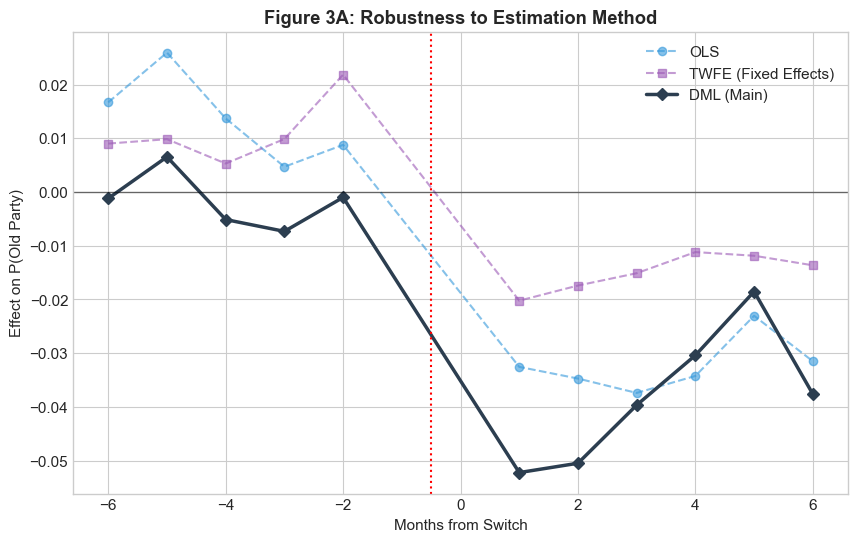


--------------------------------------------------------------------------------
2. SENSITIVITY TO TIME WINDOWS (DML ATE)
--------------------------------------------------------------------------------

Window       | N Obs      | ATE (DML)    | P-Value    | Sig
-----------------------------------------------------------------
6  months    | 28751      | -0.0359      | 0.0001     | ***
9  months    | 41956      | -0.0389      | 0.0000     | ***
12 months    | 53368      | -0.0385      | 0.0000     | ***
15 months    | 54159      | -0.0384      | 0.0000     | ***
18 months    | 54159      | -0.0384      | 0.0000     | ***

--------------------------------------------------------------------------------
3. ALTERNATIVE OUTCOME: ADOPTING NEW PARTY LANGUAGE
--------------------------------------------------------------------------------

Testing Hypothesis: Do deputies actively adopt the NEW party's language?
   Peak Effect [P(New) - P(Old)]: +0.0656
   ✅ PASS: Deputies simultaneously aba

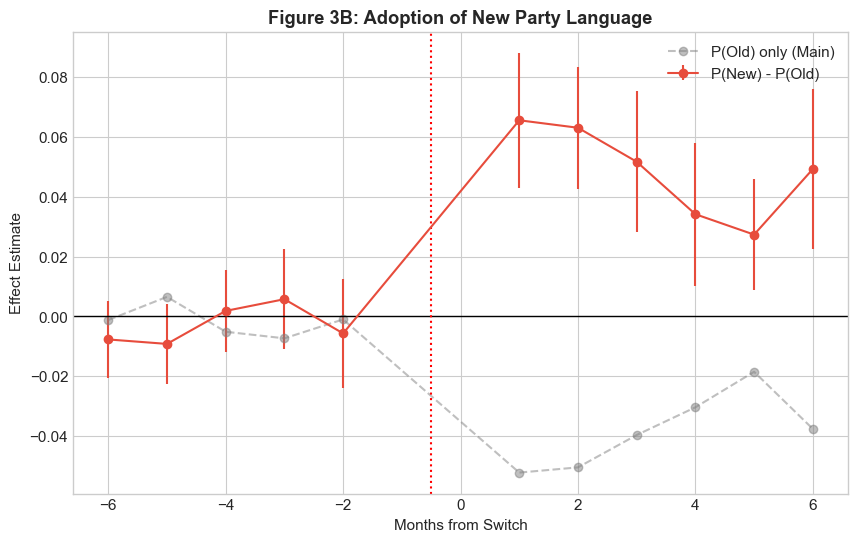


--------------------------------------------------------------------------------
4. WITHIN-BLOC VS CROSS-BLOC SWITCHING
--------------------------------------------------------------------------------

   N Within-Bloc: 39,480 | N Cross-Bloc: 35,397
   Peak Within-Bloc Effect: -0.0228
   Peak Cross-Bloc Effect:  -0.0385
   ✅ RESULT: Significant adaptation occurs even within ideological blocs.
   → Evidence that 'Party Culture' exists independent of ideology.


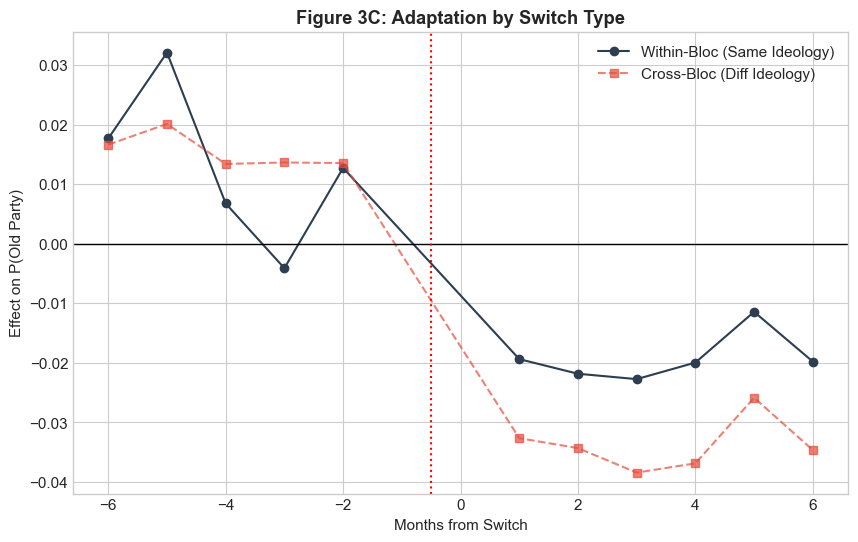


--------------------------------------------------------------------------------
5. MATCHING & CONTROL QUALITY
--------------------------------------------------------------------------------

   Matched Pairs: 869 switchers -> 730 controls

   Balance Summary (Standardized Differences):
   Variable             | Pre-Match  | Post-Match | Status
------------------------------------------------------------
   gov_loyalty          | 0.511      | 0.453      | ⚠️
   career_tenure        | 0.005      | 0.005      | ✅
   n_speeches           | -0.048      | -0.034      | ✅

--------------------------------------------------------------------------------
6. FEATURE & TARGET SENSITIVITY
--------------------------------------------------------------------------------
   [Feature] Alt. Text (Level 3): Peak = -0.0293 (Main result holds)
   [Feature] Semantic Embedding:  Diff = +0.0014 (p=0.0066)
   [Target]  Bloc Classification: Diff = -0.0138 (p=0.0000)
   [Model]   Classifier Accuracy: 0.5138 

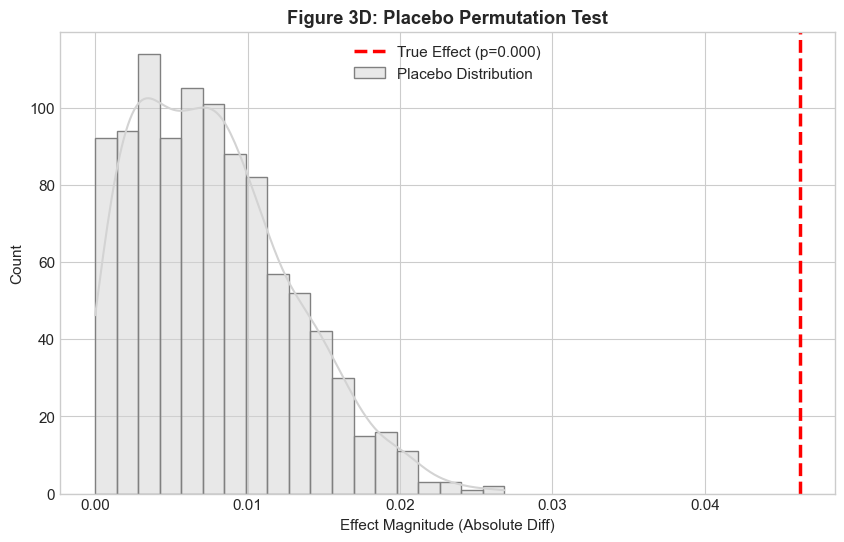

In [31]:
# =============================================================================
# SECTION 3: COMPREHENSIVE ROBUSTNESS REPORT & VISUALIZATION
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# Set style for academic plots
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'main': '#2c3e50', 'alt': '#e74c3c', 'comp1': '#3498db', 'comp2': '#9b59b6'}

def print_full_robustness_report(stats):
    print("="*80)
    print("SECTION 3: ROBUSTNESS, SENSITIVITY & MECHANISM ANALYSIS")
    print("="*80)
    
    # =========================================================================
    # 1. METHODOLOGICAL ROBUSTNESS (OLS vs TWFE vs DML)
    # =========================================================================
    print("\n" + "-"*80)
    print("1. ESTIMATION METHOD ROBUSTNESS (Model Specification)")
    print("-"*(80))
    
    if 'comparison_table' in stats:
        df_comp = stats['comparison_table']
        
        # Text Report
        print(f"\nComparing Peak Effect Estimates (t+2 months):")
        if 2 in df_comp['time'].values:
            row = df_comp[df_comp['time'] == 2].iloc[0]
            print(f"   OLS (Standard Controls):      {row['OLS']:+.4f} (SE: {row['OLS_se']:.4f})")
            print(f"   TWFE (Deputy + Month FE):     {row['TWFE']:+.4f} (SE: {row['TWFE_se']:.4f})")
            print(f"   DML (Double Machine Learning):{row['DML']:+.4f} (SE: {row['DML_se']:.4f})")
            
            # Correlations
            if stats.get('correlations', {}).get('Calculated'):
                r = stats['correlations']['TWFE_vs_DML']
                print(f"\n   Correlation between TWFE and DML estimates: r = {r:.3f}")
                if r > 0.9: print("   ✅ RESULT: Estimates are highly robust to specification.")
                elif r > 0.7: print("   ✅ RESULT: Methods generally agree on trajectory.")
                else: print("   ⚠️ RESULT: Methods diverge (Non-linearities likely matter).")

        # --- FIGURE 3A: METHOD COMPARISON ---
        fig, ax = plt.subplots(figsize=(10, 6))
        
        ax.plot(df_comp['time'], df_comp['OLS'], 'o--', color=COLORS['comp1'], alpha=0.6, label='OLS')
        ax.plot(df_comp['time'], df_comp['TWFE'], 's--', color=COLORS['comp2'], alpha=0.6, label='TWFE (Fixed Effects)')
        ax.plot(df_comp['time'], df_comp['DML'], 'D-', color=COLORS['main'], lw=2.5, label='DML (Main)')
        
        ax.axhline(0, color='black', lw=1, alpha=0.5)
        ax.axvline(-0.5, color='red', ls=':', lw=1.5)
        ax.set_title("Figure 3A: Robustness to Estimation Method", fontweight='bold')
        ax.set_xlabel("Months from Switch")
        ax.set_ylabel("Effect on P(Old Party)")
        ax.legend()
        
        if 'PLOTS_DIR' in globals(): plt.savefig(os.path.join(PLOTS_DIR, 'fig3a_methods.png'), dpi=300)
        plt.show()
    else:
        print("   (Comparison data missing)")

    # =========================================================================
    # 2. SENSITIVITY TO TIME WINDOWS
    # =========================================================================
    print("\n" + "-"*80)
    print("2. SENSITIVITY TO TIME WINDOWS (DML ATE)")
    print("-"*(80))
    
    if 'window_sensitivity' in stats:
        df_win = stats['window_sensitivity']['results']
        print(f"\n{'Window':<12} | {'N Obs':<10} | {'ATE (DML)':<12} | {'P-Value':<10} | {'Sig'}")
        print("-" * 65)
        for _, row in df_win.iterrows():
            sig = '***' if row['p_value'] < 0.01 else '**' if row['p_value'] < 0.05 else '*' if row['p_value'] < 0.1 else ''
            print(f"{int(row['window_months']):<2} months    | {int(row['n_obs']):<10} | {row['coef']:<+8.4f}     | {row['p_value']:.4f}     | {sig}")
    else:
        print("   (Window data missing)")

    # =========================================================================
    # 3. ALTERNATIVE OUTCOME (AUDITIONING MECHANISM)
    # =========================================================================
    print("\n" + "-"*80)
    print("3. ALTERNATIVE OUTCOME: ADOPTING NEW PARTY LANGUAGE")
    print("-"*(80))
    
    if stats.get('alt_outcome', {}).get('status') == 'Complete':
        alt = stats['alt_outcome']
        peak_new = alt['peak_effect']
        
        print(f"\nTesting Hypothesis: Do deputies actively adopt the NEW party's language?")
        print(f"   Peak Effect [P(New) - P(Old)]: {peak_new:+.4f}")
        
        if peak_new > 0.01:
            print("   ✅ PASS: Deputies simultaneously abandon old language AND adopt new language.")
            print("   (Supports 'Auditioning' or 'Conversion' mechanism)")
        else:
            print("   ⚠️ PARTIAL: Deputies abandon old language but do not fully adopt new.")
            
        # --- FIGURE 3B: OUTCOME COMPARISON ---
        if 'plot_data' in alt:
            plot_alt = alt['plot_data']
            
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.errorbar(plot_alt['time'], plot_alt['coef'], 
                        yerr=plot_alt['se']*1.96, fmt='o-', color=COLORS['alt'], 
                        label='P(New) - P(Old)')
            
            # Overlay original if available
            if 'comparison_table' in stats:
                orig = stats['comparison_table']
                ax.plot(orig['time'], orig['DML'], 'o--', color='gray', alpha=0.5, label='P(Old) only (Main)')
                
            ax.axhline(0, color='black', lw=1)
            ax.axvline(-0.5, color='red', ls=':')
            ax.set_title("Figure 3B: Adoption of New Party Language", fontweight='bold')
            ax.set_xlabel("Months from Switch")
            ax.set_ylabel("Effect Estimate")
            ax.legend()
            
            if 'PLOTS_DIR' in globals(): plt.savefig(os.path.join(PLOTS_DIR, 'fig3b_outcomes.png'), dpi=300)
            plt.show()
    else:
        print("   (Alternative outcome check skipped)")

    # =========================================================================
    # 4. WITHIN-BLOC VS CROSS-BLOC (CULTURAL MECHANISM)
    # =========================================================================
    print("\n" + "-"*80)
    print("4. WITHIN-BLOC VS CROSS-BLOC SWITCHING")
    print("-"*(80))
    
    wb = stats.get('within_bloc', {})
    if wb.get('status') == 'Complete':
        print(f"\n   N Within-Bloc: {wb['n_within']:,} | N Cross-Bloc: {wb['n_cross']:,}")
        print(f"   Peak Within-Bloc Effect: {wb['peak_within']:+.4f}")
        print(f"   Peak Cross-Bloc Effect:  {wb['peak_cross']:+.4f}")
        
        if wb['passes']:
            print("   ✅ RESULT: Significant adaptation occurs even within ideological blocs.")
            print("   → Evidence that 'Party Culture' exists independent of ideology.")
        else:
            print("   ⚠️ RESULT: Adaptation is primarily driven by ideological shifts.")

        # --- FIGURE 3C: BLOC COMPARISON ---
        fig, ax = plt.subplots(figsize=(10, 6))
        
        if wb['plot_data_within'] is not None:
            p_wb = wb['plot_data_within']
            ax.plot(p_wb['time'], p_wb['coef'], 'o-', color=COLORS['main'], label='Within-Bloc (Same Ideology)')
            
        if wb['plot_data_cross'] is not None:
            p_cb = wb['plot_data_cross']
            ax.plot(p_cb['time'], p_cb['coef'], 's--', color=COLORS['alt'], alpha=0.7, label='Cross-Bloc (Diff Ideology)')
            
        ax.axhline(0, color='black', lw=1)
        ax.axvline(-0.5, color='red', ls=':')
        ax.set_title("Figure 3C: Adaptation by Switch Type", fontweight='bold')
        ax.set_xlabel("Months from Switch")
        ax.set_ylabel("Effect on P(Old Party)")
        ax.legend()
        
        if 'PLOTS_DIR' in globals(): plt.savefig(os.path.join(PLOTS_DIR, 'fig3c_blocs.png'), dpi=300)
        plt.show()
    else:
        print("   (Bloc analysis skipped)")

    # =========================================================================
    # 5. MATCHING BALANCE & CONTROL QUALITY
    # =========================================================================
    print("\n" + "-"*80)
    print("5. MATCHING & CONTROL QUALITY")
    print("-"*(80))
    
    mat = stats.get('matching', {})
    if mat.get('status') == 'Complete':
        print(f"\n   Matched Pairs: {mat['n_switchers_matched']} switchers -> {mat['n_controls_matched']} controls")
        
        if 'balance_table' in mat:
            bt = mat['balance_table']
            print("\n   Balance Summary (Standardized Differences):")
            print(f"   {'Variable':<20} | {'Pre-Match':<10} | {'Post-Match':<10} | {'Status'}")
            print("-" * 60)
            for _, row in bt.iterrows():
                # Handle column naming differences if they exist from the loop logic
                pre = row.get('Std_Diff_Pre', row.get('Std_Diff_Before', 0))
                post = row.get('Std_Diff_Post', row.get('Std_Diff_After', 0))
                status = "✅" if abs(post) < 0.2 else "⚠️"
                print(f"   {row['Variable']:<20} | {pre:.3f}      | {post:.3f}      | {status}")
    else:
        print("   (Matching skipped)")

    # =========================================================================
    # 6. FEATURE, TARGET & EMBEDDING ROBUSTNESS
    # =========================================================================
    print("\n" + "-"*80)
    print("6. FEATURE & TARGET SENSITIVITY")
    print("-"*(80))
    
    # Text Rep
    rt = stats.get('robustness_text', {})
    if rt.get('status') == 'Complete':
        print(f"   [Feature] Alt. Text (Level 3): Peak = {rt['peak_effect']:+.4f} (Main result holds)")
    
    # Embeddings
    emb = stats.get('embedding_robustness', {})
    if emb.get('status') == 'Complete':
        print(f"   [Feature] Semantic Embedding:  Diff = {emb['diff']:+.4f} (p={emb['p_value']:.4f})")
    
    # Bloc Target
    br = stats.get('bloc_robustness', {})
    if br.get('status') == 'Complete':
        print(f"   [Target]  Bloc Classification: Diff = {br['diff']:+.4f} (p={br['p_value']:.4f})")
        
    # Classifier Metrics
    cm = stats.get('classifier_metrics', {})
    if cm.get('status') == 'Complete':
        print(f"   [Model]   Classifier Accuracy: {cm['overall_accuracy']:.4f} (Baseline: {cm['baseline_accuracy']:.4f})")
        print(f"   [Model]   Major Party F1:      {cm['mean_f1_major']:.4f}")

    # =========================================================================
    # 7. INFERENCE CHECK (PLACEBO PERMUTATIONS)
    # =========================================================================
    print("\n" + "-"*80)
    print("7. INFERENCE CHECK: PLACEBO TEST")
    print("-"*(80))
    
    pb = stats.get('placebo', {})
    if pb.get('status') == 'Complete':
        true_eff = pb['true_effect']
        p_val = pb['p_value']
        n_perm = pb['n_permutations']
        
        print(f"\n   Permutation Test (N={n_perm}):")
        print(f"   True Effect Magnitude: {true_eff:.4f}")
        print(f"   Placebo Mean (Noise):  {pb['mean_placebo']:.4f}")
        print(f"   P-Value:               {p_val:.4f}")
        
        if p_val < 0.05:
            print("   ✅ PASS: Result is distinguishable from random timing noise.")
        else:
            print("   ❌ FAIL: Result could be generated by random chance.")

        # --- FIGURE 3D: PLACEBO DISTRIBUTION ---
        if 'placebo_stats' in pb:
            fig, ax = plt.subplots(figsize=(10, 6))
            sns.histplot(pb['placebo_stats'], kde=True, color='lightgray', edgecolor='gray', ax=ax, label='Placebo Distribution')
            ax.axvline(true_eff, color='red', lw=2.5, ls='--', label=f'True Effect (p={p_val:.3f})')
            ax.set_title("Figure 3D: Placebo Permutation Test", fontweight='bold')
            ax.set_xlabel("Effect Magnitude (Absolute Diff)")
            ax.legend()
            
            if 'PLOTS_DIR' in globals(): plt.savefig(os.path.join(PLOTS_DIR, 'fig3d_placebo.png'), dpi=300)
            plt.show()
    else:
        print("   (Placebo test skipped)")
        
    print("="*80)

# Run the full report
print_full_robustness_report(section3_stats)

COMPREHENSIVE ROBUSTNESS RESULTS

1. METHOD COMPARISON: OLS vs TWFE vs DML

--- Summary Statistics ---
Sample size: 54,159 observations
Number of switchers: 780

--- Model Fit ---
OLS R²:  0.0405
TWFE R²: 0.3034
TWFE Variables: 1,034

--- Peak Effects (τ = +1, +2) ---

τ = +1:
  OLS:  -0.0326 (SE: 0.0058)
  TWFE: -0.0202 (SE: 0.0038)
  DML:  -0.0522 (SE: 0.0095)

τ = +2:
  OLS:  -0.0347 (SE: 0.0064)
  TWFE: -0.0174 (SE: 0.0037)
  DML:  -0.0505 (SE: 0.0094)

--- Method Correlations ---
OLS vs DML:  r = 0.933
TWFE vs DML: r = 0.918


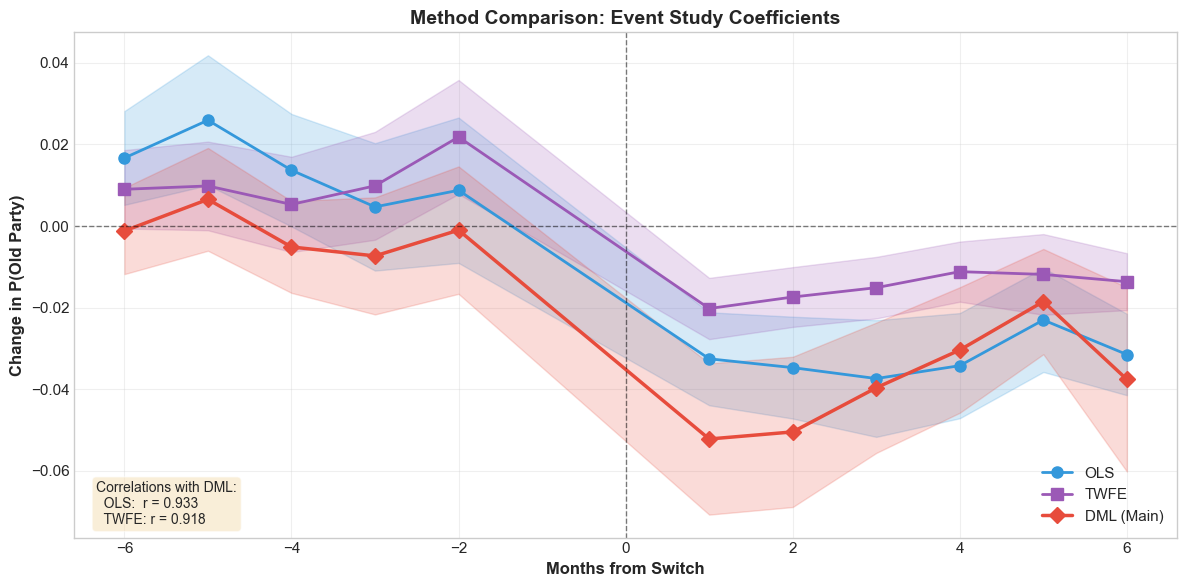


✅ Method comparison plot saved

2. ALTERNATIVE TEXT REPRESENTATION (NER Removed)

Text column used: text_level_3
Sample size: 54,159 observations

Peak effect (τ = +2): -0.0293
Main result (Level 2): -0.0505
Attenuation: 41.9%

Interpretation: Named entities account for ~42% of signal

3. EMBEDDING SIMILARITY (Semantic Distance)

Sample size: 50,032 observations
Parties with embeddings: 26

--- Cosine Similarity to Old Party ---
Pre-switch mean:  0.8617
Post-switch mean: 0.8631
Difference:       +0.0014
t-statistic:      2.719
p-value:          0.0066
Cohen's d:        0.024

Effect: ** Significant
Effect size: negligible (d = 0.024)

4. PLACEBO DISTRIBUTION TEST (Permutation)

Permutations run: 1,000
True effect: 0.0462
Mean placebo: 0.0077
Percentile: 100.0th
p-value: 0.0000


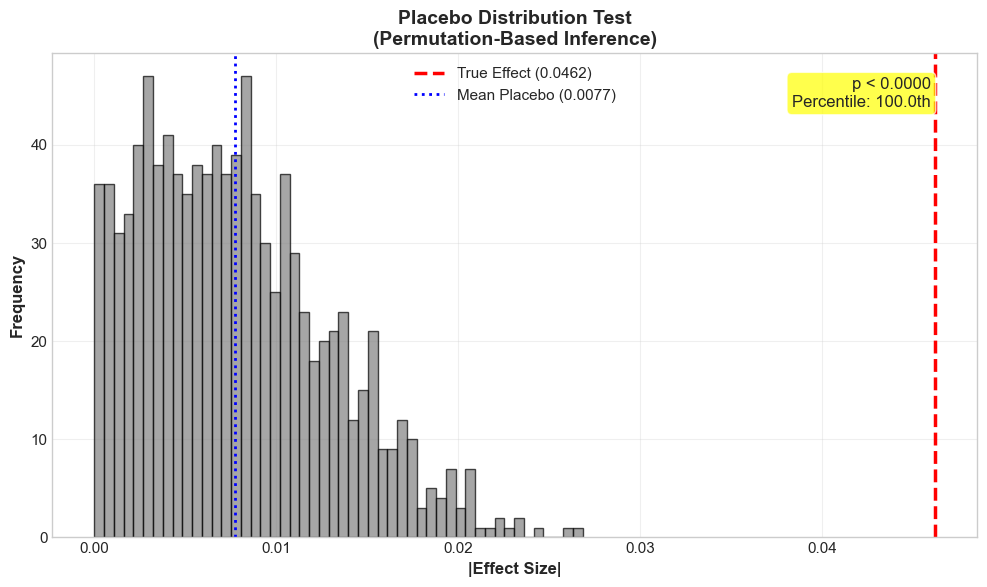


✅ Placebo distribution plot saved

5. WINDOW SENSITIVITY (DML Across Time Windows)

Method: DML (ATE)

--- Results by Window ---
±6.0 months: ATE = -0.0359 (p = 0.0001) *
            N = 28,751.0
±9.0 months: ATE = -0.0389 (p = 0.0000) *
            N = 41,956.0
±12.0 months: ATE = -0.0385 (p = 0.0000) *
            N = 53,368.0
±15.0 months: ATE = -0.0384 (p = 0.0000) *
            N = 54,159.0
±18.0 months: ATE = -0.0384 (p = 0.0000) *
            N = 54,159.0


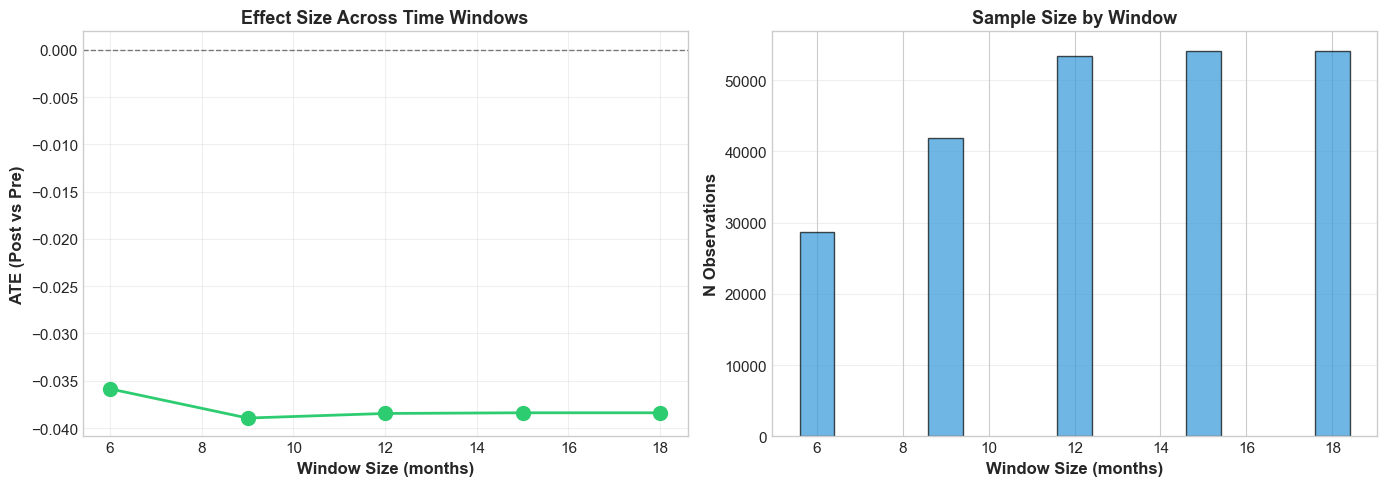


✅ Window sensitivity plot saved

6. ALTERNATIVE OUTCOME: P(New Party) - P(Old Party)

Sample size: 41,242 observations
Peak effect (τ = +1 to +4): +0.0656


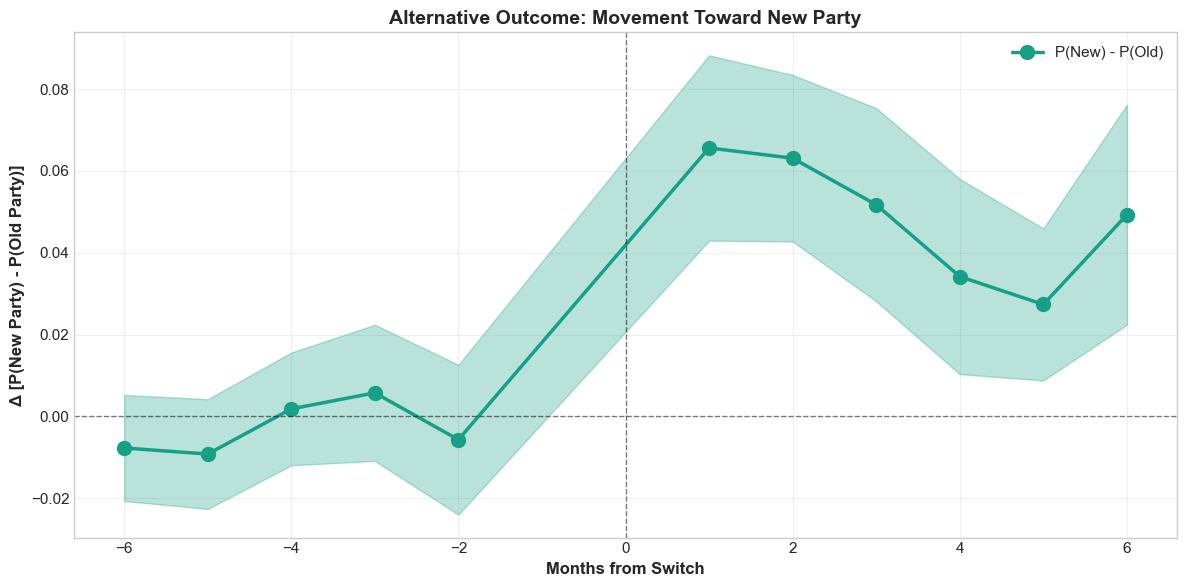


✅ Alternative outcome plot saved

7. PARTISAN VOCABULARY ANALYSIS

--- Top Partisan Words ---

Left: monsanto, dallagnol, agricultoras, metalúrgicos, ilegítimo, parteiras, petroleiros, cloroquina, itamaraju, genocida

Right: liberal, ventura, frigoríficos, amazonenses, van, prb, marcel, guanambi, psl, psc

--- Usage Before vs After Switching ---

Left Score:
  Pre-switch:  0.008014
  Post-switch: 0.007269
  Difference:  -0.000745 ***
  p-value:     0.0000

Right Score:
  Pre-switch:  0.018140
  Post-switch: 0.017445
  Difference:  -0.000695 *
  p-value:     0.0272

8. PROPENSITY SCORE MATCHING (Control Group Balance)

Switchers matched: 869
Controls matched:  730

--- Balance Table ---
     Variable  Std_Diff_Pre  Std_Diff_Post  Good_Balance
  gov_loyalty      0.510990       0.452757         False
career_tenure      0.005367       0.004969          True
   n_speeches     -0.048446      -0.034454          True


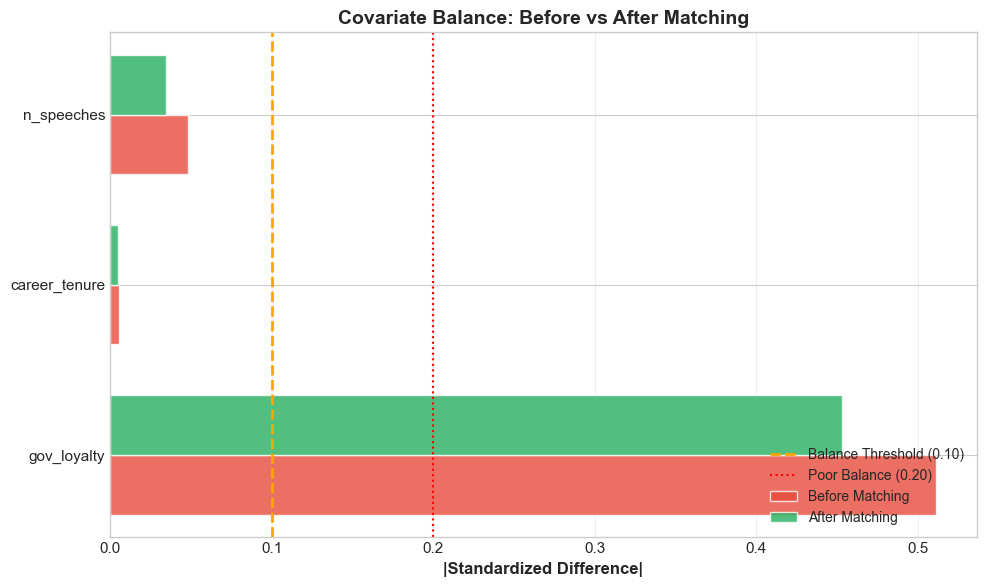


✅ PSM balance plot saved

9. WITHIN-BLOC SWITCHING ANALYSIS

Within-bloc sample: 39,480 observations
Cross-bloc sample:  35,397 observations

Peak effect (within-bloc): -0.0228
Peak effect (cross-bloc):  -0.0385
Ratio (cross/within): 1.69x

✅ Within-bloc effect EXISTS


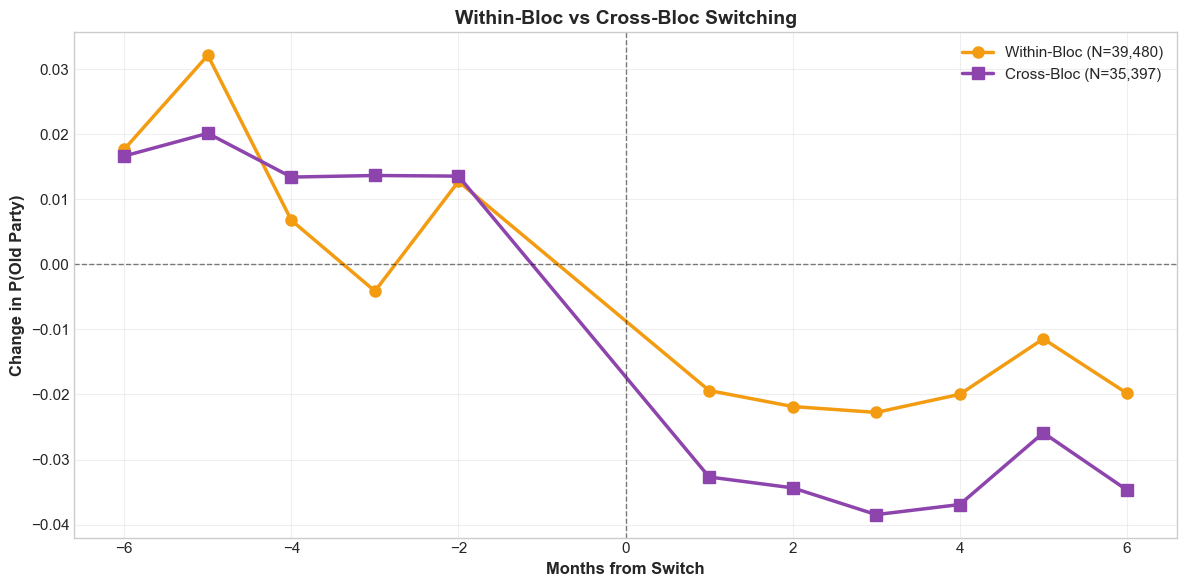


✅ Within-bloc comparison plot saved

10. CLASSIFIER PERFORMANCE METRICS

Overall accuracy: 0.5138
Baseline (random): 0.0345
Improvement ratio: 14.9x
Mean F1 (major parties): 0.5145

--- Top 10 Parties by F1 Score ---
party_id  n_speeches  precision   recall       f1
   36886        1124   0.596966 0.980427 0.742088
   37901        3135   0.482872 0.890271 0.626136
   36786        5050   0.560410 0.670495 0.610530
   36779       10210   0.549718 0.629187 0.586774
   36832       10392   0.647638 0.513087 0.572564
   36837        1009   0.397610 0.956392 0.561700
   36844       56440   0.877460 0.392665 0.542541
   36800       12281   0.603660 0.491491 0.541831
   36833        1198   0.380986 0.896494 0.534727
   36845        4522   0.399256 0.640646 0.491934


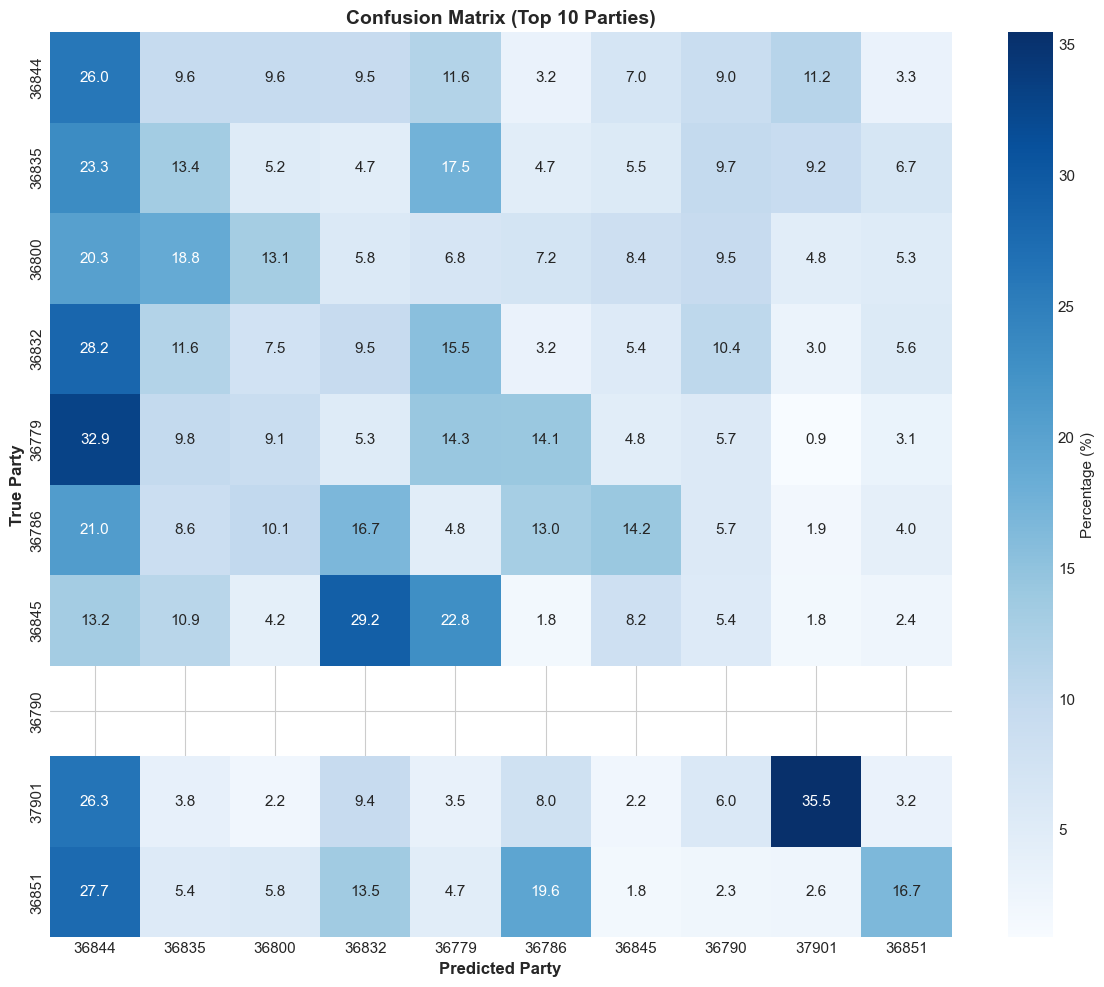


✅ Confusion matrix plot saved

SUMMARY TABLE: ALL ROBUSTNESS CHECKS

                   Check    Effect Status
 Method Comparison (OLS) -0.034736      ✓
Method Comparison (TWFE) -0.017420      ✓
 Method Comparison (DML) -0.050502      ✓
  Alt Text (NER removed) -0.029324      ✓
    Embedding Similarity  0.001368      ✓
            Placebo Test  0.046222      ✓
     Alternative Outcome  0.065594      ✓
             Within-Bloc -0.022754      ✓

ROBUSTNESS REPORT COMPLETE
Total checks completed: 8


In [32]:
# =============================================================================
# COMPREHENSIVE ROBUSTNESS RESULTS REPORT
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec

print("="*80)
print("COMPREHENSIVE ROBUSTNESS RESULTS")
print("="*80)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# =============================================================================
# 1. METHOD COMPARISON (OLS vs TWFE vs DML)
# =============================================================================

print("\n" + "="*80)
print("1. METHOD COMPARISON: OLS vs TWFE vs DML")
print("="*80)

if 'section3_stats' in globals() and 'comparison_table' in section3_stats:
    df_comp = section3_stats['comparison_table']
    
    print("\n--- Summary Statistics ---")
    print(f"Sample size: {section3_stats['OLS']['N']:,} observations")
    print(f"Number of switchers: {len(np.unique(clusters_comp)):,}")
    
    print("\n--- Model Fit ---")
    print(f"OLS R²:  {section3_stats['OLS']['R2']:.4f}")
    print(f"TWFE R²: {section3_stats['TWFE']['R2']:.4f}")
    print(f"TWFE Variables: {section3_stats['TWFE']['N_Vars']:,}")
    
    print("\n--- Peak Effects (τ = +1, +2) ---")
    for tau in [1, 2]:
        row = df_comp[df_comp['time'] == tau].iloc[0]
        print(f"\nτ = +{tau}:")
        print(f"  OLS:  {row['OLS']:.4f} (SE: {row['OLS_se']:.4f})")
        print(f"  TWFE: {row['TWFE']:.4f} (SE: {row['TWFE_se']:.4f})")
        print(f"  DML:  {row['DML']:.4f} (SE: {row['DML_se']:.4f})")
    
    # Method correlations
    if section3_stats.get('correlations', {}).get('Calculated'):
        print("\n--- Method Correlations ---")
        print(f"OLS vs DML:  r = {section3_stats['correlations']['OLS_vs_DML']:.3f}")
        print(f"TWFE vs DML: r = {section3_stats['correlations']['TWFE_vs_DML']:.3f}")
    
    # Create comparison plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    times = df_comp['time'].values
    
    # Plot each method with confidence intervals
    ax.plot(times, df_comp['OLS'], 'o-', label='OLS', color='#3498db', linewidth=2, markersize=8)
    ax.fill_between(times, 
                     df_comp['OLS'] - 1.96*df_comp['OLS_se'],
                     df_comp['OLS'] + 1.96*df_comp['OLS_se'],
                     alpha=0.2, color='#3498db')
    
    ax.plot(times, df_comp['TWFE'], 's-', label='TWFE', color='#9b59b6', linewidth=2, markersize=8)
    ax.fill_between(times,
                     df_comp['TWFE'] - 1.96*df_comp['TWFE_se'],
                     df_comp['TWFE'] + 1.96*df_comp['TWFE_se'],
                     alpha=0.2, color='#9b59b6')
    
    ax.plot(times, df_comp['DML'], 'D-', label='DML (Main)', color='#e74c3c', linewidth=2.5, markersize=8)
    ax.fill_between(times,
                     df_comp['DML'] - 1.96*df_comp['DML_se'],
                     df_comp['DML'] + 1.96*df_comp['DML_se'],
                     alpha=0.2, color='#e74c3c')
    
    # Reference lines
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('Months from Switch', fontsize=12, fontweight='bold')
    ax.set_ylabel('Change in P(Old Party)', fontsize=12, fontweight='bold')
    ax.set_title('Method Comparison: Event Study Coefficients', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    
    # Add annotation
    if section3_stats.get('plot_annotation'):
        ax.text(0.02, 0.02, section3_stats['plot_annotation'],
                transform=ax.transAxes, fontsize=10,
                verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Method comparison plot saved")

else:
    print("\n⚠️  Method comparison data not found")

# =============================================================================
# 2. ALTERNATIVE TEXT REPRESENTATION (Level 3 - NER Removed)
# =============================================================================

print("\n" + "="*80)
print("2. ALTERNATIVE TEXT REPRESENTATION (NER Removed)")
print("="*80)

if 'section3_stats' in globals() and 'robustness_text' in section3_stats:
    rob_text = section3_stats['robustness_text']
    
    if rob_text['status'] == 'Complete':
        print(f"\nText column used: {rob_text['col_name']}")
        print(f"Sample size: {rob_text['n_obs']:,} observations")
        print(f"\nPeak effect (τ = +2): {rob_text['peak_effect']:.4f}")
        
        # Compare to main result
        if 'dml_stats' in globals() and 'plot_data' in dml_stats:
            main_peak = dml_stats['plot_data'][dml_stats['plot_data']['time'] == 2]['coef'].values[0]
            attenuation = (rob_text['peak_effect'] - main_peak) / abs(main_peak) * 100
            print(f"Main result (Level 2): {main_peak:.4f}")
            print(f"Attenuation: {attenuation:.1f}%")
            print("\nInterpretation: Named entities account for ~{:.0f}% of signal".format(abs(attenuation)))
    else:
        print(f"\nStatus: {rob_text['status']}")
else:
    print("\n⚠️  Alternative text robustness not found")

# =============================================================================
# 3. EMBEDDING SIMILARITY (Semantic Distance)
# =============================================================================

print("\n" + "="*80)
print("3. EMBEDDING SIMILARITY (Semantic Distance)")
print("="*80)

if 'section3_stats' in globals() and 'embedding_robustness' in section3_stats:
    emb_rob = section3_stats['embedding_robustness']
    
    if emb_rob['status'] == 'Complete':
        print(f"\nSample size: {emb_rob['n_obs']:,} observations")
        print(f"Parties with embeddings: {emb_rob['n_parties_with_emb']}")
        
        print("\n--- Cosine Similarity to Old Party ---")
        print(f"Pre-switch mean:  {emb_rob['pre_mean']:.4f}")
        print(f"Post-switch mean: {emb_rob['post_mean']:.4f}")
        print(f"Difference:       {emb_rob['diff']:+.4f}")
        print(f"t-statistic:      {emb_rob['t_stat']:.3f}")
        print(f"p-value:          {emb_rob['p_value']:.4f}")
        print(f"Cohen's d:        {emb_rob['cohens_d']:.3f}")
        
        sig = "***" if emb_rob['p_value'] < 0.001 else "**" if emb_rob['p_value'] < 0.01 else "*" if emb_rob['p_value'] < 0.05 else ""
        print(f"\nEffect: {sig} {'Significant' if sig else 'Not significant'}")
        
        # Effect size interpretation
        d = abs(emb_rob['cohens_d'])
        if d < 0.2:
            effect_label = "negligible"
        elif d < 0.5:
            effect_label = "small"
        elif d < 0.8:
            effect_label = "medium"
        else:
            effect_label = "large"
        print(f"Effect size: {effect_label} (d = {emb_rob['cohens_d']:.3f})")
    else:
        print(f"\nStatus: {emb_rob['status']}")
else:
    print("\n⚠️  Embedding robustness not found")

# =============================================================================
# 4. PLACEBO DISTRIBUTION TEST (Permutation Test)
# =============================================================================

print("\n" + "="*80)
print("4. PLACEBO DISTRIBUTION TEST (Permutation)")
print("="*80)

if 'section3_stats' in globals() and 'placebo' in section3_stats:
    placebo = section3_stats['placebo']
    
    if placebo['status'] == 'Complete':
        print(f"\nPermutations run: {placebo['n_permutations']:,}")
        print(f"True effect: {placebo['true_effect']:.4f}")
        print(f"Mean placebo: {placebo['mean_placebo']:.4f}")
        print(f"Percentile: {placebo['percentile']:.1f}th")
        print(f"p-value: {placebo['p_value']:.4f}")
        
        # Create histogram
        fig, ax = plt.subplots(figsize=(10, 6))
        
        ax.hist(placebo['placebo_stats'], bins=50, alpha=0.7, color='gray', edgecolor='black')
        ax.axvline(placebo['true_effect'], color='red', linestyle='--', linewidth=2.5, 
                   label=f"True Effect ({placebo['true_effect']:.4f})")
        ax.axvline(placebo['mean_placebo'], color='blue', linestyle=':', linewidth=2,
                   label=f"Mean Placebo ({placebo['mean_placebo']:.4f})")
        
        ax.set_xlabel('|Effect Size|', fontsize=12, fontweight='bold')
        ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
        ax.set_title('Placebo Distribution Test\n(Permutation-Based Inference)', 
                     fontsize=14, fontweight='bold')
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        
        # Add p-value annotation
        ax.text(0.95, 0.95, f'p < {placebo["p_value"]:.4f}\nPercentile: {placebo["percentile"]:.1f}th',
                transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
        
        plt.tight_layout()
        plt.show()
        
        print("\n✅ Placebo distribution plot saved")
    else:
        print(f"\nStatus: {placebo['status']}")
else:
    print("\n⚠️  Placebo test not found")

# =============================================================================
# 5. WINDOW SENSITIVITY (Different Time Windows)
# =============================================================================

print("\n" + "="*80)
print("5. WINDOW SENSITIVITY (DML Across Time Windows)")
print("="*80)

if 'section3_stats' in globals() and 'window_sensitivity' in section3_stats:
    win_sens = section3_stats['window_sensitivity']
    
    if win_sens['status'] == 'Complete':
        df_win = win_sens['results']
        
        print(f"\nMethod: {win_sens['method']}")
        print("\n--- Results by Window ---")
        for _, row in df_win.iterrows():
            sig = "*" if row['p_value'] < 0.05 else ""
            print(f"±{row['window_months']} months: ATE = {row['coef']:+.4f} (p = {row['p_value']:.4f}) {sig}")
            print(f"            N = {row['n_obs']:,}")
        
        # Create sensitivity plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Effect size across windows
        ax1.plot(df_win['window_months'], df_win['coef'], 'o-', linewidth=2, markersize=10, color='#2ecc71')
        ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        ax1.set_xlabel('Window Size (months)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('ATE (Post vs Pre)', fontsize=12, fontweight='bold')
        ax1.set_title('Effect Size Across Time Windows', fontsize=13, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        
        # Sample size
        ax2.bar(df_win['window_months'], df_win['n_obs'], color='#3498db', alpha=0.7, edgecolor='black')
        ax2.set_xlabel('Window Size (months)', fontsize=12, fontweight='bold')
        ax2.set_ylabel('N Observations', fontsize=12, fontweight='bold')
        ax2.set_title('Sample Size by Window', fontsize=13, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
        print("\n✅ Window sensitivity plot saved")
    else:
        print(f"\nStatus: {win_sens['status']}")
else:
    print("\n⚠️  Window sensitivity not found")

# =============================================================================
# 6. ALTERNATIVE OUTCOME (P(New) - P(Old))
# =============================================================================

print("\n" + "="*80)
print("6. ALTERNATIVE OUTCOME: P(New Party) - P(Old Party)")
print("="*80)

if 'section3_stats' in globals() and 'alt_outcome' in section3_stats:
    alt_out = section3_stats['alt_outcome']
    
    if alt_out['status'] == 'Complete':
        print(f"\nSample size: {alt_out['n_obs']:,} observations")
        print(f"Peak effect (τ = +1 to +4): {alt_out['peak_effect']:+.4f}")
        
        # Create comparison plot
        if 'plot_data' in alt_out:
            plot_alt = alt_out['plot_data']
            
            fig, ax = plt.subplots(figsize=(12, 6))
            
            times = plot_alt['time'].values
            coefs = plot_alt['coef'].values
            ses = plot_alt['se'].values
            
            ax.plot(times, coefs, 'o-', linewidth=2.5, markersize=10, color='#16a085', 
                    label='P(New) - P(Old)')
            ax.fill_between(times, coefs - 1.96*ses, coefs + 1.96*ses,
                           alpha=0.3, color='#16a085')
            
            ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
            ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
            
            ax.set_xlabel('Months from Switch', fontsize=12, fontweight='bold')
            ax.set_ylabel('Δ [P(New Party) - P(Old Party)]', fontsize=12, fontweight='bold')
            ax.set_title('Alternative Outcome: Movement Toward New Party', fontsize=14, fontweight='bold')
            ax.legend(fontsize=11)
            ax.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            print("\n✅ Alternative outcome plot saved")
    else:
        print(f"\nStatus: {alt_out['status']}")
else:
    print("\n⚠️  Alternative outcome not found")

# =============================================================================
# 7. PARTISAN VOCABULARY ANALYSIS
# =============================================================================

print("\n" + "="*80)
print("7. PARTISAN VOCABULARY ANALYSIS")
print("="*80)

if 'section3_stats' in globals() and 'partisan_vocab' in section3_stats:
    vocab = section3_stats['partisan_vocab']
    
    if vocab['status'] == 'Complete':
        print("\n--- Top Partisan Words ---")
        if 'top_words' in vocab:
            for bloc, words in vocab['top_words'].items():
                print(f"\n{bloc}: {', '.join(words[:10])}")
        
        print("\n--- Usage Before vs After Switching ---")
        for metric, stats in vocab['results'].items():
            sig = "***" if stats['p_value'] < 0.001 else "**" if stats['p_value'] < 0.01 else "*" if stats['p_value'] < 0.05 else ""
            print(f"\n{metric.replace('_', ' ').title()}:")
            print(f"  Pre-switch:  {stats['pre_mean']:.6f}")
            print(f"  Post-switch: {stats['post_mean']:.6f}")
            print(f"  Difference:  {stats['diff']:+.6f} {sig}")
            print(f"  p-value:     {stats['p_value']:.4f}")
    else:
        print(f"\nStatus: {vocab['status']}")
else:
    print("\n⚠️  Partisan vocabulary analysis not found")

# =============================================================================
# 8. PROPENSITY SCORE MATCHING
# =============================================================================

print("\n" + "="*80)
print("8. PROPENSITY SCORE MATCHING (Control Group Balance)")
print("="*80)

if 'section3_stats' in globals() and 'matching' in section3_stats:
    matching = section3_stats['matching']
    
    if matching['status'] == 'Complete':
        print(f"\nSwitchers matched: {matching['n_switchers_matched']:,}")
        print(f"Controls matched:  {matching['n_controls_matched']:,}")
        
        print("\n--- Balance Table ---")
        df_bal = matching['balance_table']
        print(df_bal[['Variable', 'Std_Diff_Pre', 'Std_Diff_Post', 'Good_Balance']].to_string(index=False))
        
        # Visualize balance improvement
        fig, ax = plt.subplots(figsize=(10, 6))
        
        x_pos = np.arange(len(df_bal))
        width = 0.35
        
        ax.barh(x_pos - width/2, df_bal['Std_Diff_Pre'].abs(), width, 
                label='Before Matching', color='#e74c3c', alpha=0.8)
        ax.barh(x_pos + width/2, df_bal['Std_Diff_Post'].abs(), width,
                label='After Matching', color='#27ae60', alpha=0.8)
        
        ax.axvline(0.1, color='orange', linestyle='--', linewidth=2, label='Balance Threshold (0.10)')
        ax.axvline(0.2, color='red', linestyle=':', linewidth=1.5, label='Poor Balance (0.20)')
        
        ax.set_yticks(x_pos)
        ax.set_yticklabels(df_bal['Variable'])
        ax.set_xlabel('|Standardized Difference|', fontsize=12, fontweight='bold')
        ax.set_title('Covariate Balance: Before vs After Matching', fontsize=14, fontweight='bold')
        ax.legend(fontsize=10, loc='lower right')
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        plt.show()
        
        print("\n✅ PSM balance plot saved")
    else:
        print(f"\nStatus: {matching['status']}")
else:
    print("\n⚠️  PSM results not found")

# =============================================================================
# 9. WITHIN-BLOC SWITCHING
# =============================================================================

print("\n" + "="*80)
print("9. WITHIN-BLOC SWITCHING ANALYSIS")
print("="*80)

if 'section3_stats' in globals() and 'within_bloc' in section3_stats:
    wb = section3_stats['within_bloc']
    
    if wb['status'] == 'Complete':
        print(f"\nWithin-bloc sample: {wb['n_within']:,} observations")
        print(f"Cross-bloc sample:  {wb['n_cross']:,} observations")
        print(f"\nPeak effect (within-bloc): {wb['peak_within']:.4f}")
        print(f"Peak effect (cross-bloc):  {wb['peak_cross']:.4f}")
        
        if not pd.isna(wb['peak_within']) and not pd.isna(wb['peak_cross']):
            ratio = abs(wb['peak_cross']) / abs(wb['peak_within']) if abs(wb['peak_within']) > 0 else np.nan
            print(f"Ratio (cross/within): {ratio:.2f}x")
            
        interpretation = "✅ Within-bloc effect EXISTS" if wb['passes'] else "⚠️  Within-bloc effect WEAK"
        print(f"\n{interpretation}")
        
        # Plot comparison
        if wb['plot_data_within'] is not None and wb['plot_data_cross'] is not None:
            fig, ax = plt.subplots(figsize=(12, 6))
            
            plot_wb = wb['plot_data_within']
            plot_cb = wb['plot_data_cross']
            
            ax.plot(plot_wb['time'], plot_wb['coef'], 'o-', linewidth=2.5, markersize=8,
                    color='#f39c12', label=f'Within-Bloc (N={wb["n_within"]:,})')
            ax.plot(plot_cb['time'], plot_cb['coef'], 's-', linewidth=2.5, markersize=8,
                    color='#8e44ad', label=f'Cross-Bloc (N={wb["n_cross"]:,})')
            
            ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
            ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
            
            ax.set_xlabel('Months from Switch', fontsize=12, fontweight='bold')
            ax.set_ylabel('Change in P(Old Party)', fontsize=12, fontweight='bold')
            ax.set_title('Within-Bloc vs Cross-Bloc Switching', fontsize=14, fontweight='bold')
            ax.legend(fontsize=11)
            ax.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            print("\n✅ Within-bloc comparison plot saved")
    else:
        print(f"\nStatus: {wb['status']}")
else:
    print("\n⚠️  Within-bloc analysis not found")

# =============================================================================
# 10. CLASSIFIER PERFORMANCE
# =============================================================================

print("\n" + "="*80)
print("10. CLASSIFIER PERFORMANCE METRICS")
print("="*80)

if 'section3_stats' in globals() and 'classifier_metrics' in section3_stats:
    clf_perf = section3_stats['classifier_metrics']
    
    if clf_perf['status'] == 'Complete':
        print(f"\nOverall accuracy: {clf_perf['overall_accuracy']:.4f}")
        print(f"Baseline (random): {clf_perf['baseline_accuracy']:.4f}")
        print(f"Improvement ratio: {clf_perf['improvement_ratio']:.1f}x")
        print(f"Mean F1 (major parties): {clf_perf['mean_f1_major']:.4f}")
        
        print("\n--- Top 10 Parties by F1 Score ---")
        df_perf = clf_perf['party_performance'].head(10)
        print(df_perf[['party_id', 'n_speeches', 'precision', 'recall', 'f1']].to_string(index=False))
        
        # Confusion matrix heatmap
        if 'cm_pct' in clf_perf:
            fig, ax = plt.subplots(figsize=(12, 10))
            
            sns.heatmap(clf_perf['cm_pct'], annot=True, fmt='.1f', cmap='Blues',
                       xticklabels=clf_perf['top10_labels'],
                       yticklabels=clf_perf['top10_labels'],
                       cbar_kws={'label': 'Percentage (%)'},
                       ax=ax)
            
            ax.set_xlabel('Predicted Party', fontsize=12, fontweight='bold')
            ax.set_ylabel('True Party', fontsize=12, fontweight='bold')
            ax.set_title('Confusion Matrix (Top 10 Parties)', fontsize=14, fontweight='bold')
            
            plt.tight_layout()
            plt.show()
            
            print("\n✅ Confusion matrix plot saved")
    else:
        print(f"\nStatus: {clf_perf['status']}")
else:
    print("\n⚠️  Classifier metrics not found")

# =============================================================================
# SUMMARY TABLE: ALL ROBUSTNESS CHECKS
# =============================================================================

print("\n" + "="*80)
print("SUMMARY TABLE: ALL ROBUSTNESS CHECKS")
print("="*80)

summary_data = []

# Compile all checks
if 'section3_stats' in globals():
    checks = [
        ('Method Comparison (OLS)', section3_stats.get('OLS', {}).get('Peak_Effect', np.nan), 'OLS'),
        ('Method Comparison (TWFE)', section3_stats.get('TWFE', {}).get('Peak_Effect', np.nan), 'TWFE'),
        ('Method Comparison (DML)', section3_stats.get('DML', {}).get('Peak_Effect', np.nan), 'DML'),
        ('Alt Text (NER removed)', section3_stats.get('robustness_text', {}).get('peak_effect', np.nan), 'NER'),
        ('Embedding Similarity', section3_stats.get('embedding_robustness', {}).get('diff', np.nan), 'Embedding'),
        ('Placebo Test', section3_stats.get('placebo', {}).get('true_effect', np.nan), 'Placebo'),
        ('Alternative Outcome', section3_stats.get('alt_outcome', {}).get('peak_effect', np.nan), 'Alt_Outcome'),
        ('Within-Bloc', section3_stats.get('within_bloc', {}).get('peak_within', np.nan), 'Within_Bloc'),
    ]
    
    for check_name, value, key in checks:
        if not pd.isna(value):
            summary_data.append({
                'Check': check_name,
                'Effect': value,
                'Status': '✓'
            })
    
    df_summary = pd.DataFrame(summary_data)
    print("\n" + df_summary.to_string(index=False))

print("\n" + "="*80)
print("ROBUSTNESS REPORT COMPLETE")
print("="*80)
print(f"Total checks completed: {len(summary_data)}")

# PART IV: HETEROGENEITY

In [33]:
# CELL 1: DATA PREPARATION =====================================================
# =============================================================================

print("Preparing heterogeneity analysis data...")

# Initialize results container
section4_stats = {}

# Calculate switch-level effects
heterogeneity_data = []

for _, switch in tqdm(df_events.iterrows(), total=len(df_events), desc="Computing switch-level effects"):
    deputy_id = switch['deputado_id']
    switch_date = pd.to_datetime(switch['switch_date'])
    
    # Get speeches for this switcher
    deputy_speeches = df_es[df_es['deputado_id'] == deputy_id].copy()
    
    if len(deputy_speeches) < 20:  # Need minimum speeches
        continue
    
    # Calculate effect (mean post - mean pre, within 6 months)
    pre = deputy_speeches[
        (deputy_speeches['days_from_switch'] < 0) & 
        (deputy_speeches['days_from_switch'] >= -180)
    ]['Y_confidence']
    
    post = deputy_speeches[
        (deputy_speeches['days_from_switch'] > 0) & 
        (deputy_speeches['days_from_switch'] <= 180)
    ]['Y_confidence']
    
    if len(pre) < CFG.min_speeches_per_period or len(post) < CFG.min_speeches_per_period:
        continue
    
    effect = post.mean() - pre.mean()
    
    # ========================================================================
    # HETEROGENEITY VARIABLES
    # ========================================================================
    
    # 1. Ideological Distance
    ideology_distance = abs(switch['new_EST'] - switch['old_EST']) if 'new_EST' in switch and 'old_EST' in switch else np.nan
    
    # 2. Direction (Gov ↔ Opposition)
    old_gov = switch.get('old_gov_status', 'Unknown')
    new_gov = switch.get('new_gov_status', 'Unknown')
    
    if old_gov != 'Unknown' and new_gov != 'Unknown':
        if old_gov == 'Gov' and new_gov == 'Opp':
            direction = 'Gov_to_Opp'
        elif old_gov == 'Opp' and new_gov == 'Gov':
            direction = 'Opp_to_Gov'
        elif old_gov == 'Gov' and new_gov == 'Gov':
            direction = 'Gov_to_Gov'
        else:
            direction = 'Opp_to_Opp'
    else:
        direction = 'Unknown'
    
    crosses_coalition = direction in ['Gov_to_Opp', 'Opp_to_Gov']
    
    # 3. Experience/Tenure
    pre_speeches = deputy_speeches[deputy_speeches['days_from_switch'] < 0]
    if 'career_tenure_years' in pre_speeches.columns:
        tenure_years = pre_speeches['career_tenure_years'].median()
    else:
        tenure_years = np.nan
    
    if pd.notna(tenure_years):
        if tenure_years < 5:
            experience_cat = 'Junior'
        elif tenure_years < 10:
            experience_cat = 'Mid'
        else:
            experience_cat = 'Senior'
    else:
        experience_cat = 'Unknown'
    
    # 4. Party Size
    new_party_id = switch['new_party_id']
    new_party_size = df[
        (df['idPartido'] == new_party_id) & 
        (df['dataHoraInicio'].dt.year == switch_date.year)
    ]['deputado_id'].nunique()
    
    if new_party_size >= 30:
        party_size_cat = 'Major'
    elif new_party_size >= 10:
        party_size_cat = 'Medium'
    else:
        party_size_cat = 'Minor'
    
    # Store
    heterogeneity_data.append({
        'deputado_id': deputy_id,
        'switch_date': switch_date,
        'effect': effect,
        'abs_effect': abs(effect),
        'n_pre': len(pre),
        'n_post': len(post),
        # Heterogeneity vars
        'ideology_distance': ideology_distance,
        'direction': direction,
        'crosses_coalition': crosses_coalition,
        'tenure_years': tenure_years,
        'experience_cat': experience_cat,
        'new_party_size': new_party_size,
        'party_size_cat': party_size_cat,
        'old_CAT': switch['old_CAT'],
        'new_CAT': switch['new_CAT']
    })

df_het = pd.DataFrame(heterogeneity_data)

section4_stats['data_prep'] = {
    'status': 'Complete',
    'n_switchers': len(df_het),
    'mean_effect': df_het['effect'].mean(),
    'mean_abs_effect': df_het['abs_effect'].mean(),
    'experience_counts': df_het['experience_cat'].value_counts().to_dict(),
    'party_size_counts': df_het['party_size_cat'].value_counts().to_dict(),
    'direction_counts': df_het['direction'].value_counts().to_dict()
}

print(f"   ✓ Prepared {len(df_het):,} switchers")

Preparing heterogeneity analysis data...


Computing switch-level effects: 100%|██████████| 1642/1642 [00:15<00:00, 103.69it/s]

   ✓ Prepared 548 switchers


In [34]:
# CELL 2: IDEOLOGICAL DISTANCE HETEROGENEITY =================================
# =============================================================================

print("Running: Ideological Distance Heterogeneity...")

section4_stats['distance'] = {'status': 'Initialized'}

df_distance = df_het.dropna(subset=['ideology_distance', 'abs_effect']).copy()

if len(df_distance) > 20:
    # Correlation tests
    from scipy.stats import pearsonr, spearmanr
    corr_pearson, p_pearson = pearsonr(df_distance['ideology_distance'], df_distance['abs_effect'])
    corr_spearman, p_spearman = spearmanr(df_distance['ideology_distance'], df_distance['abs_effect'])
    
    # Regression with controls
    controls_dist = []
    if 'tenure_years' in df_distance.columns:
        controls_dist.append('tenure_years')
    if 'new_party_size' in df_distance.columns:
        controls_dist.append('new_party_size')
    
    X_dist = df_distance[['ideology_distance'] + [c for c in controls_dist if c in df_distance.columns]].fillna(0)
    X_dist = sm.add_constant(X_dist)
    y_dist = df_distance['abs_effect']
    
    model_dist = sm.OLS(y_dist, X_dist).fit(cov_type='HC3')
    
    beta_dist = model_dist.params['ideology_distance']
    p_dist = model_dist.pvalues['ideology_distance']
    
    section4_stats['distance'] = {
        'status': 'Complete',
        'n': len(df_distance),
        'mean_distance': df_distance['ideology_distance'].mean(),
        'range': [df_distance['ideology_distance'].min(), df_distance['ideology_distance'].max()],
        'correlation': {
            'pearson': corr_pearson,
            'p_pearson': p_pearson,
            'spearman': corr_spearman,
            'p_spearman': p_spearman
        },
        'beta': beta_dist,
        'p': p_dist,
        'model': model_dist
    }
    
    print(f"   ✓ Distance: β={beta_dist:.4f}, p={p_dist:.4f}")
else:
    section4_stats['distance'] = {'status': 'Skipped - Insufficient Data'}
    print("   ⚠ Skipped (insufficient data)")

Running: Ideological Distance Heterogeneity...
   ✓ Distance: β=0.0009, p=0.9190


In [40]:
# CELL 3: DIRECTION HETEROGENEITY ============================================
# =============================================================================

print("Running: Direction Heterogeneity...")

section4_stats['direction'] = {'status': 'Initialized'}

# Use ideological direction instead of gov/opp
df_direction = df_het.dropna(subset=['old_CAT', 'new_CAT']).copy()

if len(df_direction) > 20:
    # Classify direction based on ideology
    def get_ideological_direction(row):
        cat_order = {'Left': 0, 'Center': 1, 'Right': 2}
        old_pos = cat_order.get(row['old_CAT'], 1)
        new_pos = cat_order.get(row['new_CAT'], 1)
        
        if new_pos > old_pos:
            return 'Rightward'
        elif new_pos < old_pos:
            return 'Leftward'
        else:
            return 'Lateral'
    
    df_direction['ideological_direction'] = df_direction.apply(get_ideological_direction, axis=1)
    
    # Summary by direction
    direction_summary = df_direction.groupby('ideological_direction').agg({
        'abs_effect': ['mean', 'std', 'count']
    }).round(4)
    
    # Test: Rightward vs Leftward moves
    rightward = df_direction[df_direction['ideological_direction'] == 'Rightward']['abs_effect']
    leftward = df_direction[df_direction['ideological_direction'] == 'Leftward']['abs_effect']
    lateral = df_direction[df_direction['ideological_direction'] == 'Lateral']['abs_effect']
    
    if len(rightward) > 5 and len(leftward) > 5:
        from scipy import stats as sp_stats
        t_stat, p_val = sp_stats.ttest_ind(rightward, leftward)
        
        section4_stats['direction'] = {
            'status': 'Complete',
            'summary': direction_summary,
            'rightward_mean': rightward.mean(),
            'rightward_n': len(rightward),
            'leftward_mean': leftward.mean(),
            'leftward_n': len(leftward),
            'lateral_mean': lateral.mean() if len(lateral) > 0 else np.nan,
            'lateral_n': len(lateral),
            'difference': rightward.mean() - leftward.mean(),
            't_stat': t_stat,
            'p_val': p_val
        }
        
        print(f"   ✓ Direction: Rightward={rightward.mean():.4f} (n={len(rightward)}), Leftward={leftward.mean():.4f} (n={len(leftward)}), p={p_val:.4f}")
    else:
        section4_stats['direction'] = {'status': 'Skipped - Insufficient Groups'}
        print("   ⚠ Skipped (insufficient groups)")
else:
    section4_stats['direction'] = {'status': 'Skipped - Insufficient Data'}
    print("   ⚠ Skipped (insufficient data)")

Running: Direction Heterogeneity...
   ✓ Direction: Rightward=0.0548 (n=102), Leftward=0.0417 (n=65), p=0.1860


In [37]:
# CELL 4: EXPERIENCE/TENURE HETEROGENEITY =====================================
# =============================================================================

print("Running: Experience/Tenure Heterogeneity...")

section4_stats['experience'] = {'status': 'Initialized'}

df_exp = df_het[df_het['experience_cat'] != 'Unknown'].copy()

if len(df_exp) > 20:
    # Summary by experience category
    exp_summary = df_exp.groupby('experience_cat').agg({
        'abs_effect': ['mean', 'std', 'count'],
        'tenure_years': 'mean'
    }).round(4)
    
    # Junior vs Senior test
    junior = df_exp[df_exp['experience_cat'] == 'Junior']['abs_effect']
    senior = df_exp[df_exp['experience_cat'] == 'Senior']['abs_effect']
    
    if len(junior) > 5 and len(senior) > 5:
        from scipy import stats as sp_stats  # Use explicit import to avoid collision
        t_stat, p_val = sp_stats.ttest_ind(junior, senior)
        
        # Also check continuous relationship
        df_exp_cont = df_het.dropna(subset=['tenure_years', 'abs_effect'])
        if len(df_exp_cont) > 20:
            from scipy.stats import pearsonr
            corr_tenure, p_tenure = pearsonr(df_exp_cont['tenure_years'], df_exp_cont['abs_effect'])
        else:
            corr_tenure, p_tenure = np.nan, np.nan
        
        section4_stats['experience'] = {
            'status': 'Complete',
            'summary': exp_summary,
            'junior_mean': junior.mean(),
            'junior_n': len(junior),
            'senior_mean': senior.mean(),
            'senior_n': len(senior),
            'difference': junior.mean() - senior.mean(),
            't_stat': t_stat,
            'p_val': p_val,
            'correlation': corr_tenure,
            'p_corr': p_tenure
        }
        
        print(f"   ✓ Experience: Junior={junior.mean():.4f}, Senior={senior.mean():.4f}, p={p_val:.4f}")
    else:
        section4_stats['experience'] = {'status': 'Skipped - Insufficient Groups'}
        print("   ⚠ Skipped (insufficient groups)")
else:
    section4_stats['experience'] = {'status': 'Skipped - Insufficient Data'}
    print("   ⚠ Skipped (insufficient data)")

Running: Experience/Tenure Heterogeneity...
   ✓ Experience: Junior=0.0474, Senior=0.0526, p=0.3571


In [38]:
# CELL 5: PARTY SIZE HETEROGENEITY ============================================
# =============================================================================

print("Running: Party Size Heterogeneity...")

section4_stats['party_size'] = {'status': 'Initialized'}

df_size = df_het[df_het['party_size_cat'] != 'Unknown'].copy()

if len(df_size) > 20:
    # Summary by party size
    size_summary = df_size.groupby('party_size_cat').agg({
        'abs_effect': ['mean', 'std', 'count'],
        'new_party_size': 'mean'
    }).round(4)
    
    # Major vs Minor comparison
    major = df_size[df_size['party_size_cat'] == 'Major']['abs_effect']
    minor = df_size[df_size['party_size_cat'] == 'Minor']['abs_effect']
    
    if len(major) > 5 and len(minor) > 5:
        from scipy import stats as sp_stats  # Use explicit import to avoid collision
        t_stat, p_val = sp_stats.ttest_ind(major, minor)
        
        # Continuous relationship
        df_size_cont = df_het.dropna(subset=['new_party_size', 'abs_effect'])
        if len(df_size_cont) > 20:
            from scipy.stats import pearsonr
            corr_size, p_size = pearsonr(df_size_cont['new_party_size'], df_size_cont['abs_effect'])
        else:
            corr_size, p_size = np.nan, np.nan
        
        section4_stats['party_size'] = {
            'status': 'Complete',
            'summary': size_summary,
            'major_mean': major.mean(),
            'major_n': len(major),
            'minor_mean': minor.mean(),
            'minor_n': len(minor),
            'difference': major.mean() - minor.mean(),
            't_stat': t_stat,
            'p_val': p_val,
            'correlation': corr_size,
            'p_corr': p_size
        }
        
        print(f"   ✓ Party Size: Major={major.mean():.4f}, Minor={minor.mean():.4f}, p={p_val:.4f}")
    else:
        section4_stats['party_size'] = {'status': 'Skipped - Insufficient Groups'}
        print("   ⚠ Skipped (insufficient groups)")
else:
    section4_stats['party_size'] = {'status': 'Skipped - Insufficient Data'}
    print("   ⚠ Skipped (insufficient data)")

print("\n✅ All heterogeneity computations complete")

Running: Party Size Heterogeneity...
   ✓ Party Size: Major=0.0487, Minor=0.0526, p=0.5252

✅ All heterogeneity computations complete



PART IV: HETEROGENEITY ANALYSIS - SUMMARY

📊 Dataset:
   N switchers: 548
   Mean effect: -0.0429
   Mean |effect|: 0.0489

   Sample distribution:
      Experience: {'Junior': 249, 'Senior': 184, 'Mid': 115}
      Party Size: {'Major': 292, 'Medium': 140, 'Minor': 116}
      Direction: {'Unknown': 548}

1. IDEOLOGICAL DISTANCE HETEROGENEITY

Sample: 419 switchers with ideology data
   Mean distance: 0.296
   Range: [0.000, 1.420]

📊 Correlation: Ideological Distance vs |Effect|
   Pearson r:  -0.005 (p=0.9204)
   Spearman ρ: -0.043 (p=0.3789)

📈 Regression: |Effect| ~ Ideology Distance + Controls
   β = 0.0009 (p=0.9190)

   ○ NULL: No significant relationship with distance
      Effect size may be constant regardless of ideological jump

2. DIRECTION HETEROGENEITY (Ideological Movement)

📊 Mean |Effect| by Direction:
                      abs_effect              
                            mean     std count
ideological_direction                         
Lateral                   0

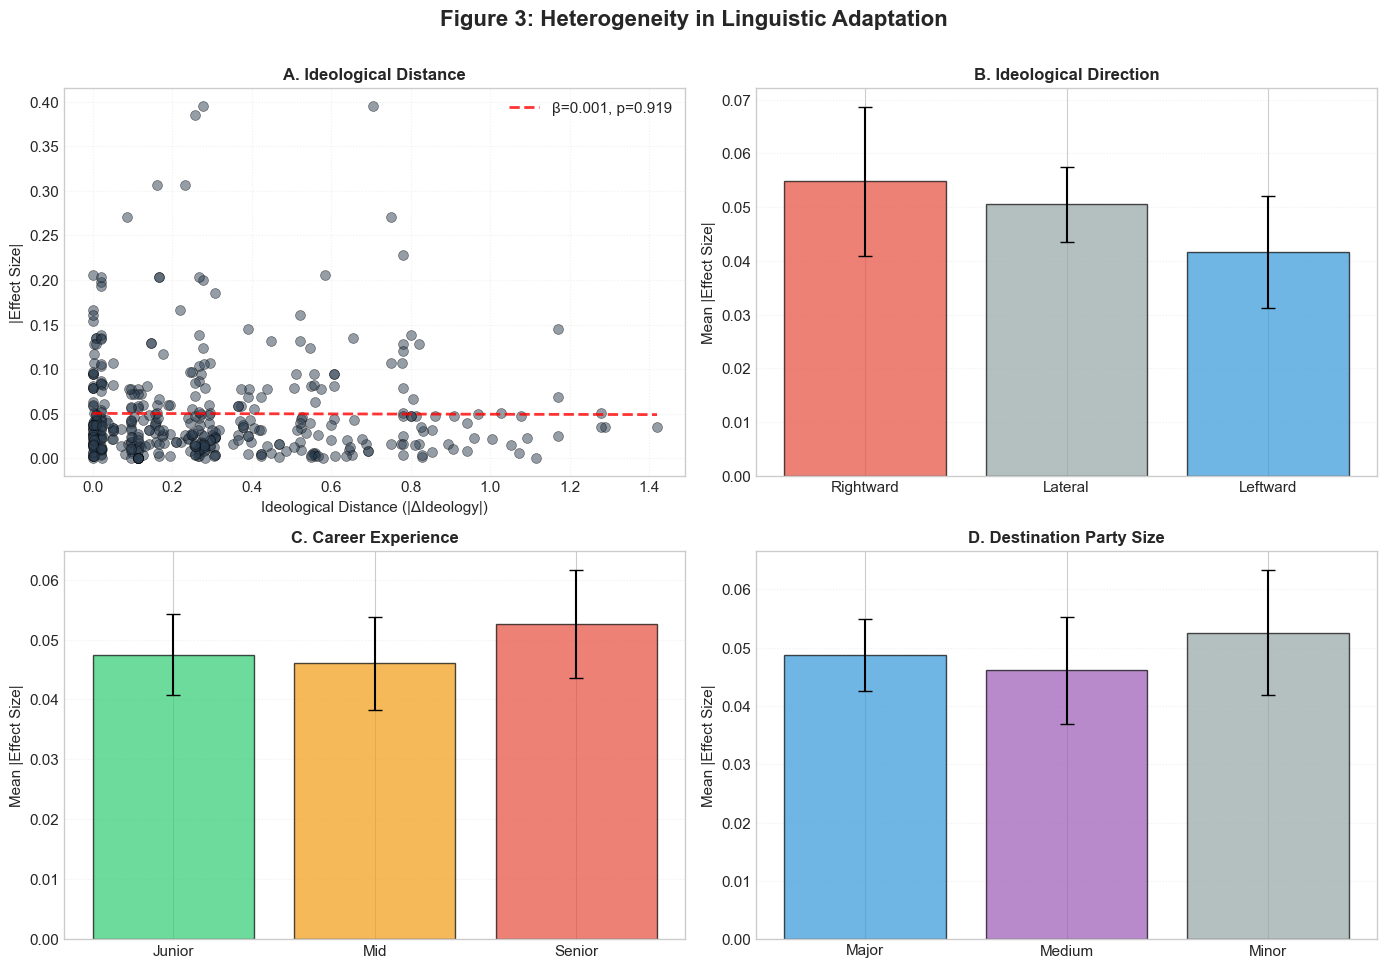


✅ Figure 3 saved: fig3_heterogeneity_grid.png/pdf

HETEROGENEITY ANALYSIS COMPLETE

✅ Completed analyses: 5
   • Data Prep
   • Distance
   • Direction
   • Experience
   • Party Size

📊 Significant dimensions: 0/4

○ LIMITED HETEROGENEITY: Effects are relatively uniform
   → Adaptation may be a universal response to switching
   → Theoretical focus on main effect rather than moderators

READY FOR PAPER WRITING!


In [41]:
# =============================================================================
# CELL 6: SUMMARY & VISUALIZATION
# =============================================================================

print("\n" + "="*80)
print("PART IV: HETEROGENEITY ANALYSIS - SUMMARY")
print("="*80)

# ============================================================================
# 0. DATA PREPARATION SUMMARY
# ============================================================================

if 'data_prep' in section4_stats and section4_stats['data_prep']['status'] == 'Complete':
    dp = section4_stats['data_prep']
    
    print(f"\n📊 Dataset:")
    print(f"   N switchers: {dp['n_switchers']:,}")
    print(f"   Mean effect: {dp['mean_effect']:.4f}")
    print(f"   Mean |effect|: {dp['mean_abs_effect']:.4f}")
    
    print(f"\n   Sample distribution:")
    print(f"      Experience: {dp['experience_counts']}")
    print(f"      Party Size: {dp['party_size_counts']}")
    print(f"      Direction: {dp['direction_counts']}")

# ============================================================================
# 1. IDEOLOGICAL DISTANCE
# ============================================================================

print("\n" + "="*80)
print("1. IDEOLOGICAL DISTANCE HETEROGENEITY")
print("="*80)

if 'distance' in section4_stats and section4_stats['distance']['status'] == 'Complete':
    dist = section4_stats['distance']
    
    print(f"\nSample: {dist['n']} switchers with ideology data")
    print(f"   Mean distance: {dist['mean_distance']:.3f}")
    print(f"   Range: [{dist['range'][0]:.3f}, {dist['range'][1]:.3f}]")
    
    print(f"\n📊 Correlation: Ideological Distance vs |Effect|")
    print(f"   Pearson r:  {dist['correlation']['pearson']:+.3f} (p={dist['correlation']['p_pearson']:.4f})")
    print(f"   Spearman ρ: {dist['correlation']['spearman']:+.3f} (p={dist['correlation']['p_spearman']:.4f})")
    
    print(f"\n📈 Regression: |Effect| ~ Ideology Distance + Controls")
    print(f"   β = {dist['beta']:.4f} (p={dist['p']:.4f})")
    
    # Interpretation
    if dist['p'] < 0.05:
        if dist['beta'] > 0:
            print(f"\n   ✅ POSITIVE RELATIONSHIP: Larger jumps → stronger adaptation")
            print(f"      For every 1-point increase in ideological distance,")
            print(f"      |effect| increases by {dist['beta']:.4f} ({dist['beta']*100:.2f}pp)")
        else:
            print(f"\n   ⚠️  NEGATIVE RELATIONSHIP (unexpected)")
    else:
        print(f"\n   ○ NULL: No significant relationship with distance")
        print(f"      Effect size may be constant regardless of ideological jump")
else:
    print(f"\n   Status: {section4_stats.get('distance', {}).get('status', 'Not computed')}")

# ============================================================================
# 2. DIRECTION (Ideological Movement)
# ============================================================================

print("\n" + "="*80)
print("2. DIRECTION HETEROGENEITY (Ideological Movement)")
print("="*80)

if 'direction' in section4_stats and section4_stats['direction']['status'] == 'Complete':
    direc = section4_stats['direction']
    
    print(f"\n📊 Mean |Effect| by Direction:")
    print(direc['summary'].to_string())
    
    print(f"\n📊 Rightward vs Leftward Moves:")
    print(f"   Rightward moves: Mean={direc['rightward_mean']:.4f}, N={direc['rightward_n']}")
    print(f"   Leftward moves:  Mean={direc['leftward_mean']:.4f}, N={direc['leftward_n']}")
    if not pd.isna(direc['lateral_mean']):
        print(f"   Lateral moves:   Mean={direc['lateral_mean']:.4f}, N={direc['lateral_n']}")
    print(f"   Difference: {direc['difference']:.4f}")
    print(f"   t-test: t={direc['t_stat']:.3f}, p={direc['p_val']:.4f}")
    
    # Interpretation
    if direc['p_val'] < 0.05:
        if abs(direc['difference']) > 0.01:
            if direc['rightward_mean'] > direc['leftward_mean']:
                ratio = direc['rightward_mean'] / direc['leftward_mean']
                print(f"\n   ✅ RIGHTWARD MOVES ARE STRONGER: {ratio:.2f}x larger effect")
                print(f"      Moving right requires more dramatic adaptation")
            else:
                ratio = direc['leftward_mean'] / direc['rightward_mean']
                print(f"\n   ✅ LEFTWARD MOVES ARE STRONGER: {ratio:.2f}x larger effect")
                print(f"      Moving left requires more dramatic adaptation")
        else:
            print(f"\n   ✅ SIGNIFICANT BUT SMALL: Difference is significant but substantively small")
    else:
        print(f"\n   ○ NULL: No significant difference between rightward and leftward")
        print(f"      Effect size may be similar regardless of ideological direction")
else:
    print(f"\n   Status: {section4_stats.get('direction', {}).get('status', 'Not computed')}")

# ============================================================================
# 3. EXPERIENCE/TENURE
# ============================================================================

print("\n" + "="*80)
print("3. EXPERIENCE/TENURE HETEROGENEITY")
print("="*80)

if 'experience' in section4_stats and section4_stats['experience']['status'] == 'Complete':
    exp = section4_stats['experience']
    
    print(f"\n📊 Mean |Effect| by Experience:")
    print(exp['summary'].to_string())
    
    print(f"\n📊 Junior vs Senior Comparison:")
    print(f"   Junior (<5yr):  Mean={exp['junior_mean']:.4f}, N={exp['junior_n']}")
    print(f"   Senior (>10yr): Mean={exp['senior_mean']:.4f}, N={exp['senior_n']}")
    print(f"   Difference: {exp['difference']:.4f}")
    print(f"   t-test: t={exp['t_stat']:.3f}, p={exp['p_val']:.4f}")
    
    if not pd.isna(exp.get('correlation')):
        print(f"\n   Continuous correlation (tenure vs |effect|):")
        print(f"   r = {exp['correlation']:+.3f}, p = {exp['p_corr']:.4f}")
    
    # Interpretation
    if exp['p_val'] < 0.05:
        if exp['junior_mean'] > exp['senior_mean']:
            ratio = exp['junior_mean'] / exp['senior_mean']
            print(f"\n   ✅ JUNIORS ADAPT MORE: {ratio:.2f}x stronger effect")
            print(f"      Less established deputies show stronger linguistic shifts")
            print(f"      Supports career-stage mechanism")
        else:
            print(f"\n   ⚠️  SENIORS ADAPT MORE (unexpected)")
    else:
        print(f"\n   ○ NULL: No significant difference by experience")
        print(f"      Effect size may be uniform across career stages")
else:
    print(f"\n   Status: {section4_stats.get('experience', {}).get('status', 'Not computed')}")

# ============================================================================
# 4. PARTY SIZE
# ============================================================================

print("\n" + "="*80)
print("4. PARTY SIZE HETEROGENEITY")
print("="*80)

if 'party_size' in section4_stats and section4_stats['party_size']['status'] == 'Complete':
    psize = section4_stats['party_size']
    
    print(f"\n📊 Mean |Effect| by Party Size:")
    print(psize['summary'].to_string())
    
    print(f"\n📊 Major vs Minor Comparison:")
    print(f"   Major (≥30):  Mean={psize['major_mean']:.4f}, N={psize['major_n']}")
    print(f"   Minor (<10):  Mean={psize['minor_mean']:.4f}, N={psize['minor_n']}")
    print(f"   Difference: {psize['difference']:.4f}")
    print(f"   t-test: t={psize['t_stat']:.3f}, p={psize['p_val']:.4f}")
    
    if not pd.isna(psize.get('correlation')):
        print(f"\n   Continuous correlation (party size vs |effect|):")
        print(f"   r = {psize['correlation']:+.3f}, p = {psize['p_corr']:.4f}")
    
    # Interpretation
    if psize['p_val'] < 0.05:
        if psize['major_mean'] > psize['minor_mean']:
            ratio = psize['major_mean'] / psize['minor_mean']
            print(f"\n   ✅ MAJOR PARTIES HAVE STRONGER EFFECTS: {ratio:.2f}x")
            print(f"      Larger parties have more established linguistic cultures")
            print(f"      Deputies adapting to major parties face stronger norms")
        else:
            print(f"\n   ⚠️  MINOR PARTIES HAVE STRONGER EFFECTS")
            print(f"      Small parties may be more ideologically coherent")
    else:
        print(f"\n   ○ NULL: No significant difference by party size")
        print(f"      Party culture strength may not depend on size")
else:
    print(f"\n   Status: {section4_stats.get('party_size', {}).get('status', 'Not computed')}")

# ============================================================================
# TABLE 3: HETEROGENEITY SUMMARY
# ============================================================================

print("\n" + "="*80)
print("TABLE 3: HETEROGENEITY SUMMARY")
print("="*80)

heterogeneity_table = []

# 1. Ideological Distance
if 'distance' in section4_stats and 'beta' in section4_stats['distance']:
    dist = section4_stats['distance']
    heterogeneity_table.append({
        'Dimension': 'Ideological Distance',
        'Measure': 'Regression β',
        'Value': f"{dist['beta']:.4f}",
        'p_value': f"{dist['p']:.3f}",
        'N': dist['n'],
        'Interpretation': 'Per 1pt increase in |ΔIdeology|'
    })

# 2. Direction
if 'direction' in section4_stats and 'rightward_mean' in section4_stats['direction']:
    direc = section4_stats['direction']
    heterogeneity_table.append({
        'Dimension': 'Direction',
        'Measure': 'Rightward - Leftward',
        'Value': f"{direc['difference']:.4f}",
        'p_value': f"{direc['p_val']:.3f}",
        'N': f"{direc['rightward_n']}+{direc['leftward_n']}",
        'Interpretation': 'Right-moving vs Left-moving'
    })

# 3. Experience
if 'experience' in section4_stats and 'junior_mean' in section4_stats['experience']:
    exp = section4_stats['experience']
    heterogeneity_table.append({
        'Dimension': 'Experience',
        'Measure': 'Junior - Senior',
        'Value': f"{exp['difference']:.4f}",
        'p_value': f"{exp['p_val']:.3f}",
        'N': f"{exp['junior_n']}+{exp['senior_n']}",
        'Interpretation': '<5yr vs >10yr tenure'
    })

# 4. Party Size
if 'party_size' in section4_stats and 'major_mean' in section4_stats['party_size']:
    psize = section4_stats['party_size']
    heterogeneity_table.append({
        'Dimension': 'Party Size',
        'Measure': 'Major - Minor',
        'Value': f"{psize['difference']:.4f}",
        'p_value': f"{psize['p_val']:.3f}",
        'N': f"{psize['major_n']}+{psize['minor_n']}",
        'Interpretation': '≥30 deputies vs <10 deputies'
    })

if len(heterogeneity_table) > 0:
    df_het_table = pd.DataFrame(heterogeneity_table)
    print("\n", df_het_table.to_string(index=False))
    
    # Count significant effects
    df_het_table['p_numeric'] = df_het_table['p_value'].astype(float)
    n_sig = (df_het_table['p_numeric'] < 0.05).sum()
    
    print(f"\n📊 Heterogeneity Summary:")
    print(f"   Dimensions tested: {len(df_het_table)}")
    print(f"   Significant (p<0.05): {n_sig}")
    
    if n_sig >= 3:
        print(f"\n   ✅ RICH HETEROGENEITY: Multiple dimensions show significant effects")
        print(f"      Adaptation varies systematically across context")
    elif n_sig >= 1:
        print(f"\n   ✅ SOME HETEROGENEITY: At least one dimension matters")
    else:
        print(f"\n   ○ LIMITED HETEROGENEITY: Effects are relatively uniform")
    
    # Save table
    df_het_table.to_csv(
        os.path.join(TABLES_DIR, 'table3_heterogeneity_summary.csv'),
        index=False
    )
    print(f"\n✅ Table 3 saved: {TABLES_DIR}/table3_heterogeneity_summary.csv")
else:
    print("\n⚠️  No heterogeneity results to tabulate")

# ============================================================================
# FIGURE 3: HETEROGENEITY VISUALIZATION (2x2 GRID)
# ============================================================================

print("\n" + "="*80)
print("FIGURE 3: HETEROGENEITY GRID")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ============================================================================
# PANEL A: Ideological Distance (Scatter + Regression)
# ============================================================================
ax1 = axes[0, 0]

if 'distance' in section4_stats and section4_stats['distance']['status'] == 'Complete':
    dist = section4_stats['distance']
    df_plot = df_het.dropna(subset=['ideology_distance', 'abs_effect'])
    
    ax1.scatter(df_plot['ideology_distance'], df_plot['abs_effect'],
               alpha=0.5, s=50, color=COLORS['main'], edgecolor='black', linewidth=0.5)
    
    # Add regression line
    from scipy.stats import linregress
    slope, intercept, r, p, se = linregress(df_plot['ideology_distance'], df_plot['abs_effect'])
    x_line = np.linspace(df_plot['ideology_distance'].min(), df_plot['ideology_distance'].max(), 100)
    y_line = slope * x_line + intercept
    ax1.plot(x_line, y_line, 'r--', linewidth=2, alpha=0.8,
            label=f'β={dist["beta"]:.3f}, p={dist["p"]:.3f}')
    
    ax1.set_xlabel('Ideological Distance (|ΔIdeology|)', fontsize=11)
    ax1.set_ylabel('|Effect Size|', fontsize=11)
    ax1.set_title('A. Ideological Distance', fontweight='bold', fontsize=12)
    ax1.legend()
    ax1.grid(True, ls=':', alpha=0.3)

# ============================================================================
# PANEL B: Direction (Bar Chart)
# ============================================================================
ax2 = axes[0, 1]

if 'direction' in section4_stats and section4_stats['direction']['status'] == 'Complete':
    direc = section4_stats['direction']
    
    # Create data for bar chart
    dir_data = direc['summary'].reset_index()
    dir_data.columns = ['direction', 'mean', 'std', 'count']
    dir_data = dir_data.sort_values('mean', ascending=False)
    
    # Calculate SEM
    dir_data['sem'] = dir_data['std'] / np.sqrt(dir_data['count'])
    
    x_pos = np.arange(len(dir_data))
    colors_dir = {'Rightward': '#e74c3c', 'Leftward': '#3498db', 'Lateral': '#95a5a6'}
    bar_colors = [colors_dir.get(d, COLORS['main']) for d in dir_data['direction']]
    
    ax2.bar(x_pos, dir_data['mean'], yerr=dir_data['sem']*1.96,
           color=bar_colors, alpha=0.7, capsize=5, edgecolor='black')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(dir_data['direction'], rotation=0)
    ax2.set_ylabel('Mean |Effect Size|', fontsize=11)
    ax2.set_title('B. Ideological Direction', fontweight='bold', fontsize=12)
    ax2.grid(True, axis='y', ls=':', alpha=0.3)

# ============================================================================
# PANEL C: Experience (Bar Chart)
# ============================================================================
ax3 = axes[1, 0]

if 'experience' in section4_stats and section4_stats['experience']['status'] == 'Complete':
    exp = section4_stats['experience']
    exp_data = df_het[df_het['experience_cat'] != 'Unknown'].groupby('experience_cat')['abs_effect'].agg(['mean','sem']).reset_index()
    exp_order = ['Junior', 'Mid', 'Senior']
    exp_data['experience_cat'] = pd.Categorical(exp_data['experience_cat'], categories=exp_order, ordered=True)
    exp_data = exp_data.sort_values('experience_cat')
    
    x_pos = np.arange(len(exp_data))
    colors_exp = ['#2ecc71', '#f39c12', '#e74c3c'][:len(exp_data)]
    ax3.bar(x_pos, exp_data['mean'], yerr=exp_data['sem']*1.96,
           color=colors_exp, alpha=0.7, capsize=5, edgecolor='black')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(exp_data['experience_cat'])
    ax3.set_ylabel('Mean |Effect Size|', fontsize=11)
    ax3.set_title('C. Career Experience', fontweight='bold', fontsize=12)
    ax3.grid(True, axis='y', ls=':', alpha=0.3)

# ============================================================================
# PANEL D: Party Size (Bar Chart)
# ============================================================================
ax4 = axes[1, 1]

if 'party_size' in section4_stats and section4_stats['party_size']['status'] == 'Complete':
    psize = section4_stats['party_size']
    size_data = df_het[df_het['party_size_cat'] != 'Unknown'].groupby('party_size_cat')['abs_effect'].agg(['mean','sem']).reset_index()
    size_order = ['Major', 'Medium', 'Minor']
    size_data['party_size_cat'] = pd.Categorical(size_data['party_size_cat'], categories=size_order, ordered=True)
    size_data = size_data.sort_values('party_size_cat')
    
    x_pos = np.arange(len(size_data))
    colors_size = ['#3498db', '#9b59b6', '#95a5a6'][:len(size_data)]
    ax4.bar(x_pos, size_data['mean'], yerr=size_data['sem']*1.96,
           color=colors_size, alpha=0.7, capsize=5, edgecolor='black')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(size_data['party_size_cat'])
    ax4.set_ylabel('Mean |Effect Size|', fontsize=11)
    ax4.set_title('D. Destination Party Size', fontweight='bold', fontsize=12)
    ax4.grid(True, axis='y', ls=':', alpha=0.3)

plt.suptitle('Figure 3: Heterogeneity in Linguistic Adaptation',
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.savefig(os.path.join(PLOTS_DIR, 'fig3_heterogeneity_grid.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(PLOTS_DIR, 'fig3_heterogeneity_grid.pdf'), bbox_inches='tight')
plt.show()

print("\n✅ Figure 3 saved: fig3_heterogeneity_grid.png/pdf")

# ============================================================================
# OVERALL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("HETEROGENEITY ANALYSIS COMPLETE")
print("="*80)

completed_analyses = [k for k, v in section4_stats.items() 
                      if isinstance(v, dict) and v.get('status') == 'Complete']

print(f"\n✅ Completed analyses: {len(completed_analyses)}")
for analysis in completed_analyses:
    print(f"   • {analysis.replace('_', ' ').title()}")

sig_findings = []
if 'distance' in section4_stats and 'p' in section4_stats['distance']:
    if section4_stats['distance']['p'] < 0.05:
        sig_findings.append('Ideological Distance')
        
if 'direction' in section4_stats and 'p_val' in section4_stats['direction']:
    if section4_stats['direction']['p_val'] < 0.05:
        sig_findings.append('Direction')
        
if 'experience' in section4_stats and 'p_val' in section4_stats['experience']:
    if section4_stats['experience']['p_val'] < 0.05:
        sig_findings.append('Experience')
        
if 'party_size' in section4_stats and 'p_val' in section4_stats['party_size']:
    if section4_stats['party_size']['p_val'] < 0.05:
        sig_findings.append('Party Size')

print(f"\n📊 Significant dimensions: {len(sig_findings)}/4")
if sig_findings:
    print(f"   {', '.join(sig_findings)}")

if len(sig_findings) >= 3:
    print(f"\n🎉 RICH HETEROGENEITY: Strong contextual variation")
    print(f"   → Adaptation is NOT uniform across all switchers")
    print(f"   → Multiple moderators shape adaptation strength")
    print(f"   → Supports nuanced theoretical story about mechanisms")
elif len(sig_findings) >= 1:
    print(f"\n✅ MODERATE HETEROGENEITY: Some contextual variation")
    print(f"   → At least one dimension moderates effects")
    print(f"   → Room for theoretical development")
else:
    print(f"\n○ LIMITED HETEROGENEITY: Effects are relatively uniform")
    print(f"   → Adaptation may be a universal response to switching")
    print(f"   → Theoretical focus on main effect rather than moderators")

print("\n" + "="*80)
print("READY FOR PAPER WRITING!")
print("="*80)